# Japan Birth Trends (1899–2023) and history events

In [1]:
!pip install japanize_matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import japanize_matplotlib

,total_births,male_births,female_births
max,2696638.0,1380008.0,1316630.0


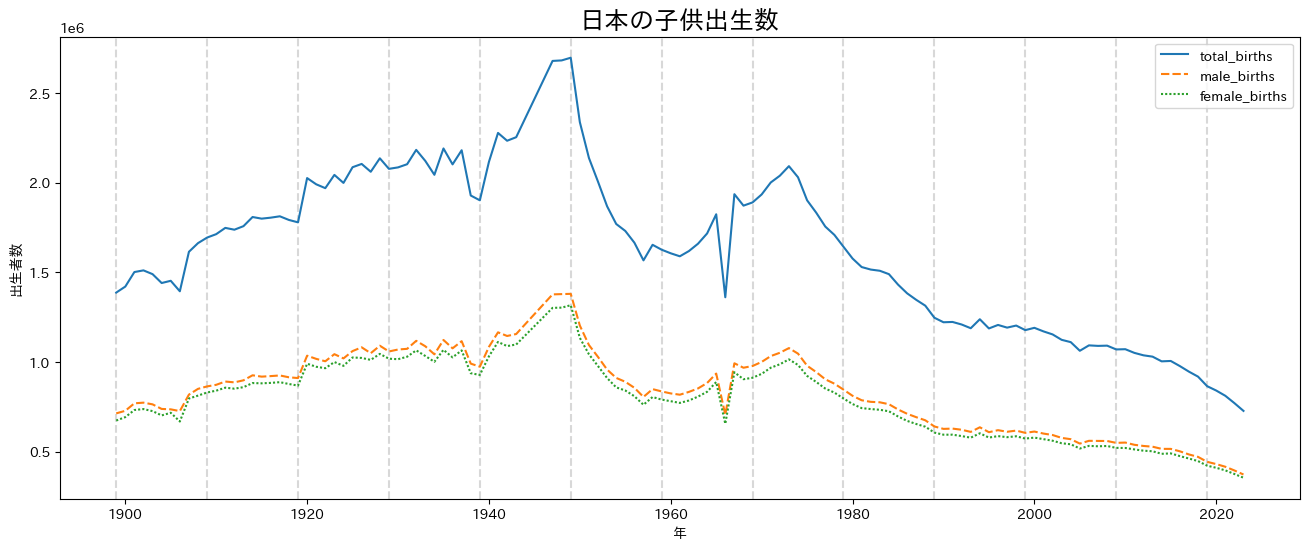

In [3]:
df_japan_birth_stats = pd.read_csv('/kaggle/input/datasets/hideos/japan-birth-statistics-18992023/japan_birth_statistics_1899_2023.csv')
df_japan_birth_stats['year'] = df_japan_birth_stats['year'].astype(int)
df_japan_birth_stats = df_japan_birth_stats.set_index('year')
df_japan_birth_stats = df_japan_birth_stats[['total_births', 'male_births', 'female_births']]

plt.figure(figsize=(16,6))
plt.title("日本の子供出生数", fontsize=18)
plt.xlabel("年")
plt.ylabel("出生者数")
for year in range(df_japan_birth_stats.index.min(),df_japan_birth_stats.index.max(),10):
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.3)

sns.lineplot(data=df_japan_birth_stats)
df_japan_birth_stats.describe().loc[['max']]

In [4]:
import requests
import pandas as pd
from io import BytesIO
import os

# 国立公文書館アジア歴史資料センターからのデータをクローリングし、クレンジングする。データフレーム化する
base_url = 'https://www.jacar.go.jp/learning/'
csv_path = 'data/menu.csv'
csv_url = os.path.join(base_url, csv_path)

print(f"Attempting to download raw CSV bytes from: {csv_url} and decode with 'utf-8' encoding directly in pandas.")

# Download the CSV content as raw bytes
try:
    response_csv = requests.get(csv_url)
    response_csv.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    raw_csv_bytes = response_csv.content # Get raw bytes

    # Read the CSV content bytes into a pandas DataFrame, specifying 'utf-8' encoding
    df_timeline = pd.read_csv(BytesIO(raw_csv_bytes), header=None, encoding='utf-8')

    print(f"Successfully downloaded and loaded CSV from {csv_url}. Shape: {df_timeline.shape}")

except requests.exceptions.RequestException as e:
    print(f"Error downloading CSV: {e}")
    df_timeline = pd.DataFrame()
except Exception as e:
    print(f"Error processing CSV content: {e}")
    df_timeline = pd.DataFrame()

# Define column names based on the JavaScript `CreateTable` function
if not df_timeline.empty:
    df_timeline.columns = ['id', 'cat', 'uid', 'year', 'month', 'day', 'title']
    print("DataFrame with corrected column names and encoding:")
    display(df_timeline.head())

Attempting to download raw CSV bytes from: https://www.jacar.go.jp/learning/data/menu.csv and decode with 'utf-8' encoding directly in pandas.
Successfully downloaded and loaded CSV from https://www.jacar.go.jp/learning/data/menu.csv. Shape: (286, 7)
DataFrame with corrected column names and encoding:


,id,cat,uid,year,month,day,title
0,Y10,C20,NaN,1853,7,8.0,米国ペリー艦隊が浦賀に来航する
1,Y10,C20,NaN,1853,8,22.0,露国プゥチャーチン艦隊が長崎に来航する
2,Y10,C10,NaN,1853,10,17.0,幕府が大船建造を解禁する
3,Y10,C20,3.0,1854,3,31.0,日米和親条約が調印される
4,Y10,C20,NaN,1855,2,7.0,日露和親条約が調印される


In [5]:
df_timeline.isnull().sum()

id         0
cat        0
uid      180
year       0
month      0
day        3
title      0
dtype: int64

In [6]:
df_timeline.describe()

,uid,year,month,day
count,106.000000,286.000000,286.000000,283.000000
mean,59.518868,1916.548951,6.790210,15.674912
std,32.674216,33.037183,3.367238,9.196841
min,3.000000,1840.000000,1.000000,1.000000
25%,32.250000,1888.250000,4.000000,8.000000
50%,60.500000,1925.000000,7.000000,15.000000
75%,86.750000,1945.000000,10.000000,24.000000
max,115.000000,1972.000000,12.000000,31.000000


In [7]:
df_timeline

,id,cat,uid,year,month,day,title
0,Y10,C20,NaN,1853,7,8.0,米国ペリー艦隊が浦賀に来航する
1,Y10,C20,NaN,1853,8,22.0,露国プゥチャーチン艦隊が長崎に来航する
2,Y10,C10,NaN,1853,10,17.0,幕府が大船建造を解禁する
3,Y10,C20,3.0,1854,3,31.0,日米和親条約が調印される
4,Y10,C20,NaN,1855,2,7.0,日露和親条約が調印される
...,...,...,...,...,...,...,...
281,Y60,C10,NaN,1968,6,26.0,小笠原諸島が返還される
282,Y60,C20,NaN,1969,4,18.0,太平洋諸島信託統治地域に関する日本国とアメリカ合衆国との協定が調印される（同年7月7日発効）
283,Y60,C10,NaN,1970,3,15.0,大阪万博が開催される
284,Y60,C10,NaN,1972,5,15.0,沖縄が返還される


In [8]:
import numpy as np

# 1. Fill missing values in 'month' and 'day' columns with 1
df_timeline['month'] = df_timeline['month'].fillna(1)
df_timeline['day'] = df_timeline['day'].fillna(1)

# 2. Convert 'year', 'month', 'day' columns to integer type
df_timeline['year'] = df_timeline['year'].astype(int)
df_timeline['month'] = df_timeline['month'].astype(int)
df_timeline['day'] = df_timeline['day'].astype(int)

# 3. Create a new 'date' column combining 'year', 'month', 'day'
# Handle potential errors during conversion by coercing invalid dates to NaT
df_timeline['date'] = pd.to_datetime(df_timeline[['year', 'month', 'day']], errors='coerce')

# 4. Reorder DataFrame columns
new_column_order = ['year', 'month', 'day', 'title', 'date', 'id', 'cat', 'uid']
df_timeline = df_timeline[new_column_order]

print("DataFrame after cleansing and restructuring:")
display(df_timeline.head())

print("\nDataFrame Info after cleansing and restructuring:")
df_timeline.info()

DataFrame after cleansing and restructuring:


,year,month,day,title,date,id,cat,uid
0,1853,7,8,米国ペリー艦隊が浦賀に来航する,1853-07-08,Y10,C20,NaN
1,1853,8,22,露国プゥチャーチン艦隊が長崎に来航する,1853-08-22,Y10,C20,NaN
2,1853,10,17,幕府が大船建造を解禁する,1853-10-17,Y10,C10,NaN
3,1854,3,31,日米和親条約が調印される,1854-03-31,Y10,C20,3.0
4,1855,2,7,日露和親条約が調印される,1855-02-07,Y10,C20,NaN



DataFrame Info after cleansing and restructuring:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    286 non-null    int64         
 1   month   286 non-null    int64         
 2   day     286 non-null    int64         
 3   title   286 non-null    object        
 4   date    286 non-null    datetime64[ns]
 5   id      286 non-null    object        
 6   cat     286 non-null    object        
 7   uid     106 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 18.0+ KB


In [9]:
df_japan_birth_stats = df_japan_birth_stats.reset_index()

print("df_japan_birth_stats after resetting index:")
display(df_japan_birth_stats.head())

df_japan_birth_stats after resetting index:


,year,total_births,male_births,female_births
0,2023,727288,372603,354685
1,2022,770759,395257,375502
2,2021,811622,415903,395719
3,2020,840835,430713,410122
4,2019,865239,443430,421809


df_japan_birth_birth_stats と df_timeline を 'year' カラムをキーとして結合します。内側結合（inner join）を使用して、両方のデータフレームに存在する年のみを保持します。

In [10]:
df_merged_data = pd.merge(df_japan_birth_stats, df_timeline, on='year', how='inner')

print("Merged DataFrame head:")
display(df_merged_data.head())

print("\nMerged DataFrame info:")
df_merged_data.info()

Merged DataFrame head:


,year,total_births,male_births,female_births,month,day,title,date,id,cat,uid
0,1972,2038682,1051389,987293,5,15,沖縄が返還される,1972-05-15,Y60,C10,NaN
1,1972,2038682,1051389,987293,9,29,日中共同声明が調印される（日中国交正常化）,1972-09-29,Y60,C20,NaN
2,1970,1934239,1000403,933836,3,15,大阪万博が開催される,1970-03-15,Y60,C10,NaN
3,1969,1889815,977687,912128,4,18,太平洋諸島信託統治地域に関する日本国とアメリカ合衆国との協定が調印される（同年7月7日発効）,1969-04-18,Y60,C20,NaN
4,1968,1871839,967996,903843,6,26,小笠原諸島が返還される,1968-06-26,Y60,C10,NaN



Merged DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   year           175 non-null    int64         
 1   total_births   175 non-null    int64         
 2   male_births    175 non-null    int64         
 3   female_births  175 non-null    int64         
 4   month          175 non-null    int64         
 5   day            175 non-null    int64         
 6   title          175 non-null    object        
 7   date           175 non-null    datetime64[ns]
 8   id             175 non-null    object        
 9   cat            175 non-null    object        
 10  uid            62 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 15.2+ KB


In [11]:
!pip install japanize_matplotlib -q

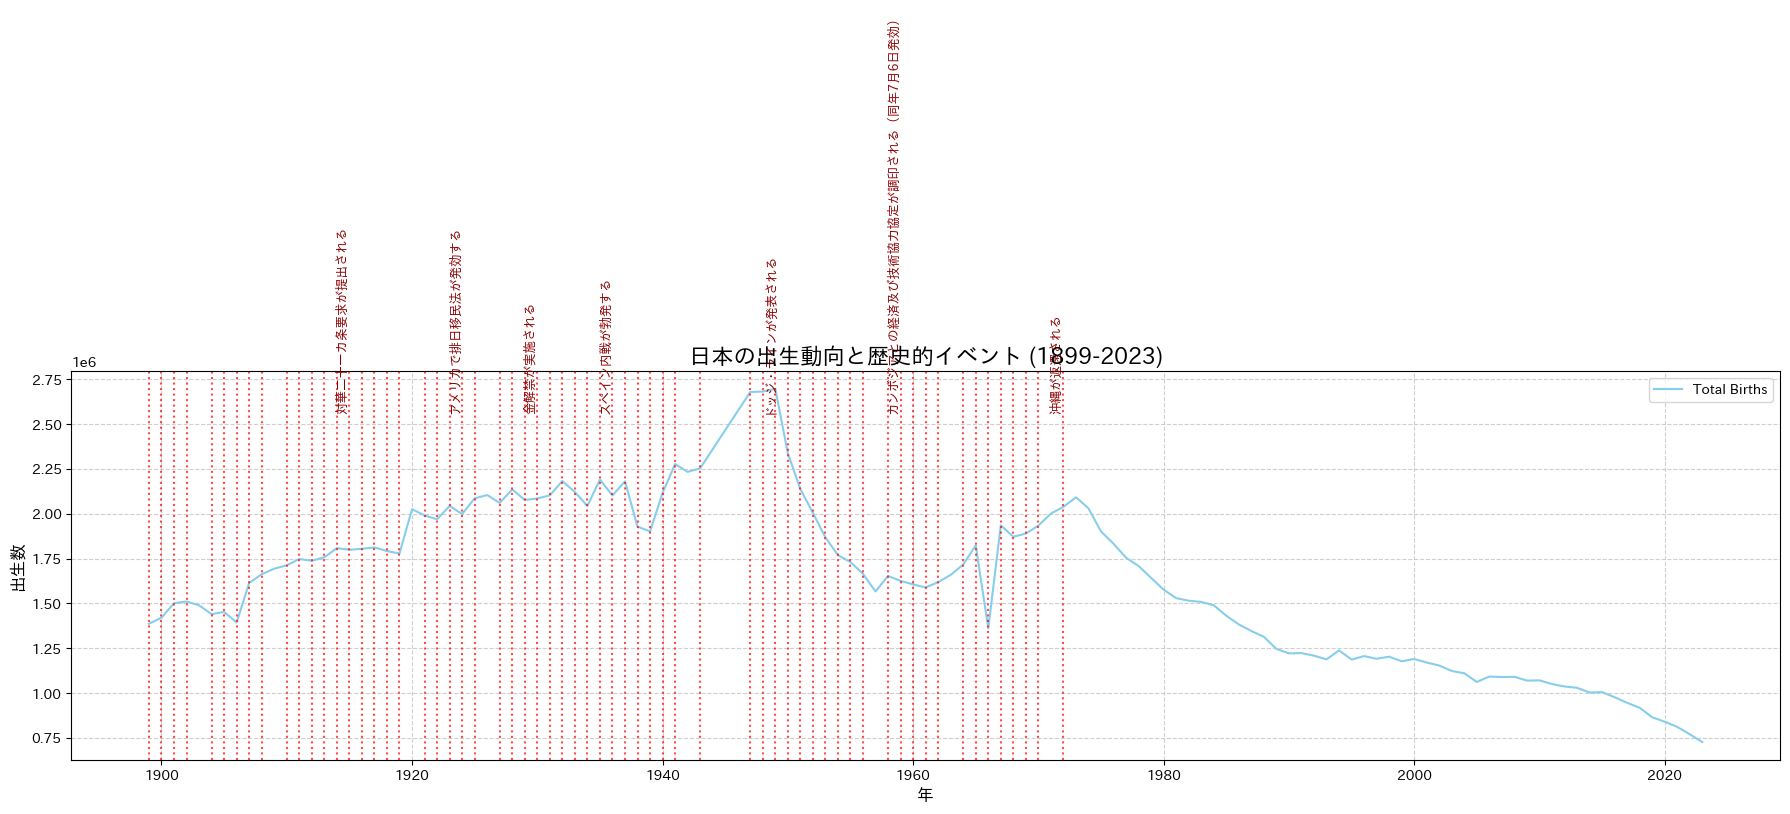

In [12]:


plt.figure(figsize=(18, 8))
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='Total Births', color='skyblue')

# Filter for unique years in merged data to avoid multiple labels for the same year
unique_events = df_merged_data.drop_duplicates(subset=['year']).copy()

# Add vertical lines for historical events
for index, row in unique_events.iterrows():
    plt.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7)
    # Annotate with event title, adjusting position to avoid overlap
    # Only annotate a few significant events or space them out
    if index % 20 == 0: # Annotate every 20th unique event for readability
        plt.text(row['year'], df_japan_birth_stats['total_births'].max() * 0.95,
                 row['title'], rotation=90, verticalalignment='bottom',
                 horizontalalignment='right', fontsize=9, color='darkred')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16) # Updated title to Japanese
plt.xlabel('年', fontsize=12) # Updated xlabel to Japanese
plt.ylabel('出生数', fontsize=12) # Updated ylabel to Japanese
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_17/4154255290.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


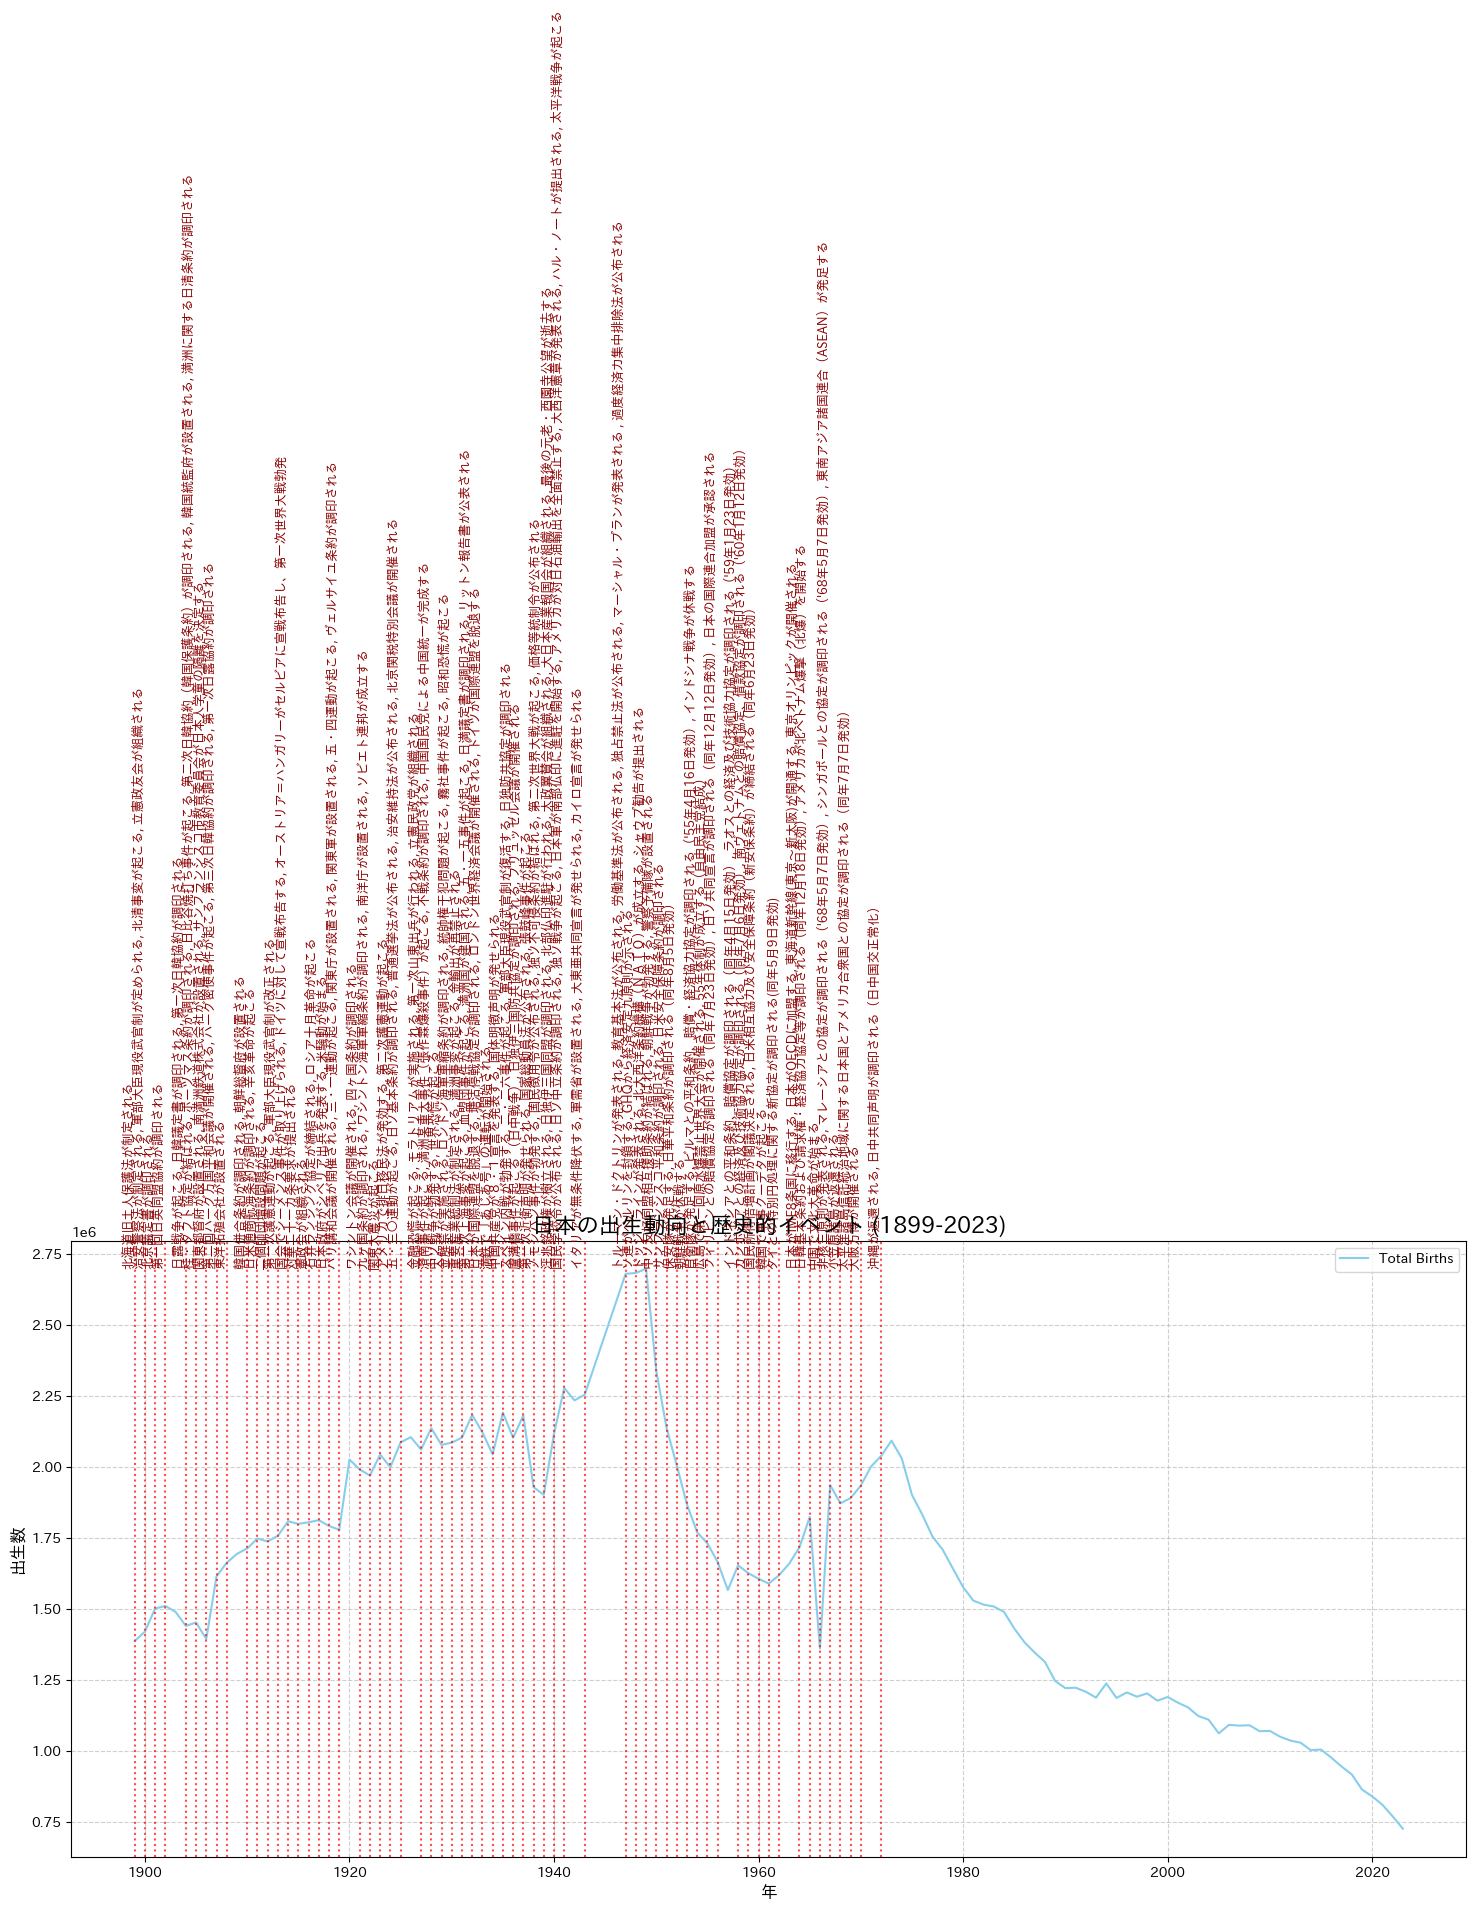

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

plt.figure(figsize=(18, 8))
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='Total Births', color='skyblue')

# Group events by year and concatenate titles for annotation
yearly_events = df_merged_data.groupby('year')['title'].apply(lambda x: ', '.join(x)).reset_index()

# Add vertical lines and annotations for historical events
for index, row in yearly_events.iterrows():
    plt.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7)
    # Annotate with event title(s), adjusting position to avoid overlap
    plt.text(row['year'], df_japan_birth_stats['total_births'].max(), # * 0.95,
             row['title'], rotation=90, verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, color='darkred')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16)
plt.xlabel('年', fontsize=12)
plt.ylabel('出生数', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

1940年代後半から1960年代までの出生者が次の世代を生まなかった可能性がある

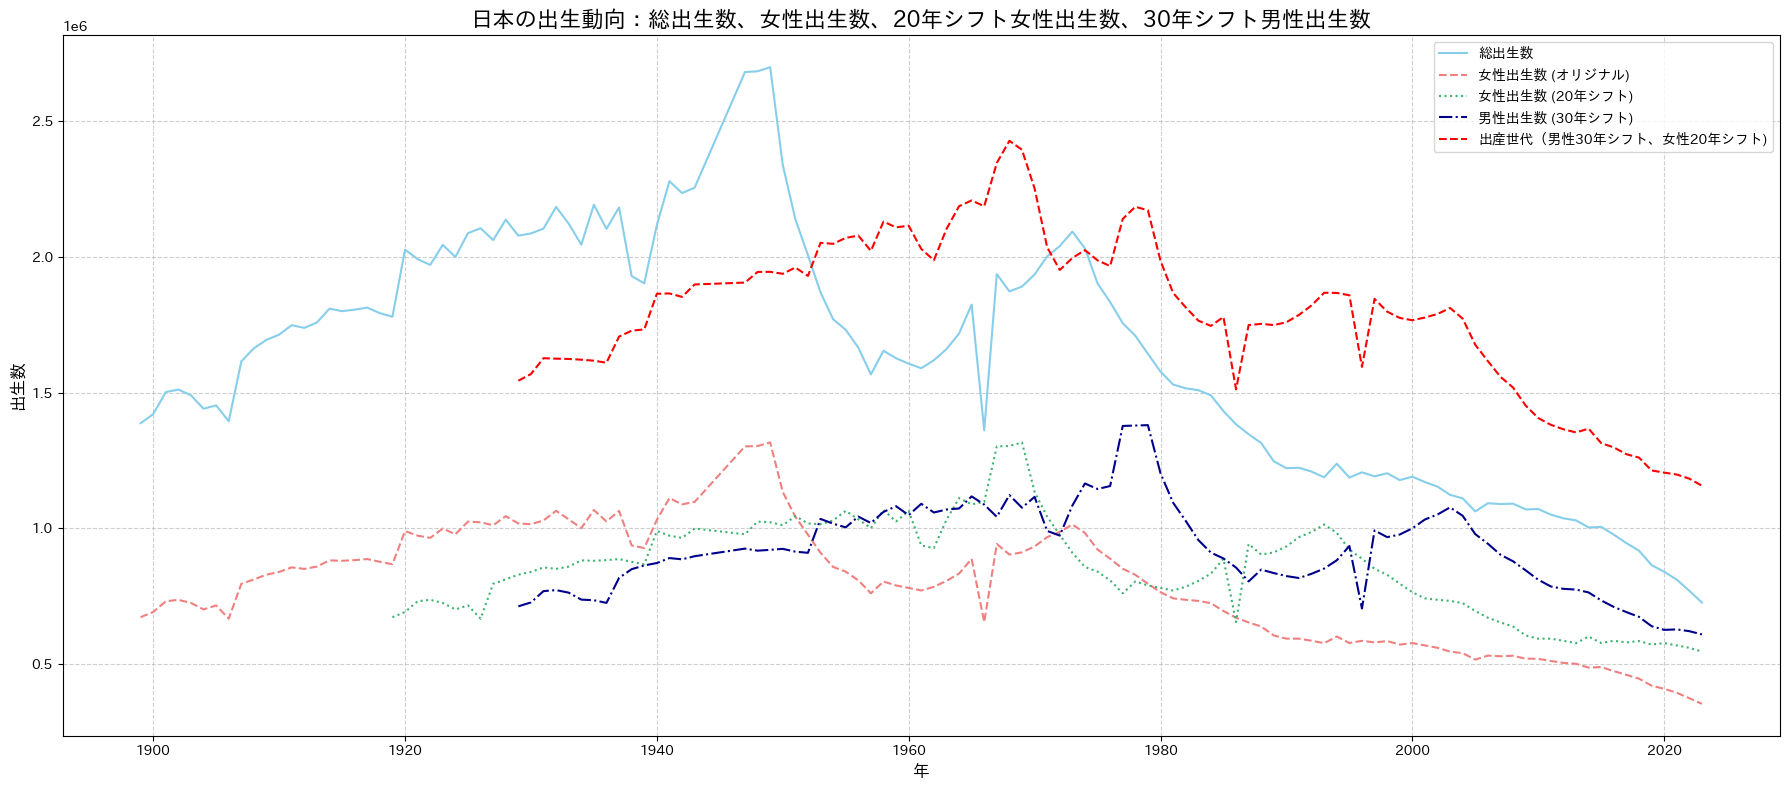

In [14]:
df_japan_birth_stats['female_births_shifted_20'] = df_japan_birth_stats['female_births'].shift(periods=-20, axis=0)
df_japan_birth_stats['male_births_shifted_30'] = df_japan_birth_stats['male_births'].shift(periods=-30, axis=0)
df_japan_birth_stats['total_shifted_female_and_male'] = df_japan_birth_stats['female_births_shifted_20'] + df_japan_birth_stats['male_births_shifted_30']


plt.figure(figsize=(18, 8))
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='総出生数', color='skyblue')
sns.lineplot(data=df_japan_birth_stats, x='year', y='female_births', label='女性出生数 (オリジナル)', color='lightcoral', linestyle='--')
sns.lineplot(data=df_japan_birth_stats, x='year', y='female_births_shifted_20', label='女性出生数 (20年シフト)', color='mediumseagreen', linestyle=':')
sns.lineplot(data=df_japan_birth_stats, x='year', y='male_births_shifted_30', label='男性出生数 (30年シフト)', color='darkblue', linestyle='-.')
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_shifted_female_and_male',label = '出産世代（男性30年シフト、女性20年シフト)',color = 'red', linestyle = 'dashed') 

plt.title('日本の出生動向：総出生数、女性出生数、20年シフト女性出生数、30年シフト男性出生数', fontsize=16)
plt.xlabel('年', fontsize=12)
plt.ylabel('出生数', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

見ずらい。もしかすると、文字数の高い時、（Eventsの多い時）の後に、人口が一時的に減る可能性がある

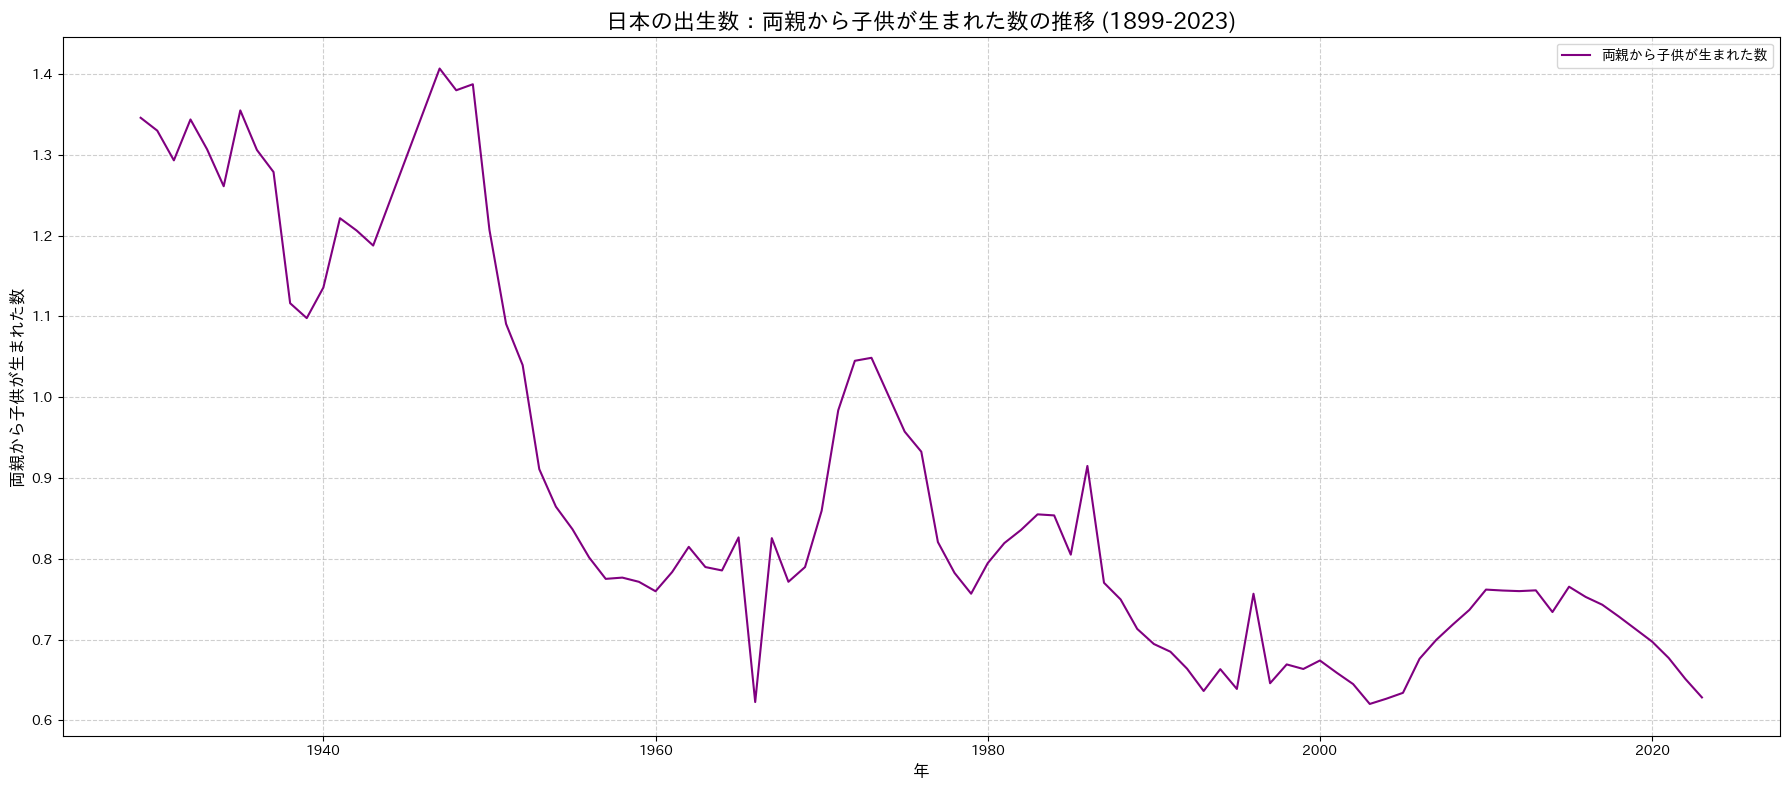

In [15]:
df_japan_birth_stats['children_per_generation'] = df_japan_birth_stats['total_births'] / df_japan_birth_stats['total_shifted_female_and_male']

plt.figure(figsize=(18, 8))
sns.lineplot(data=df_japan_birth_stats, x='year', y='children_per_generation', label='両親から子供が生まれた数', color='purple')

plt.title('日本の出生数：両親から子供が生まれた数の推移 (1899-2023)', fontsize=16)
plt.xlabel('年', fontsize=12)
plt.ylabel('両親から子供が生まれた数', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

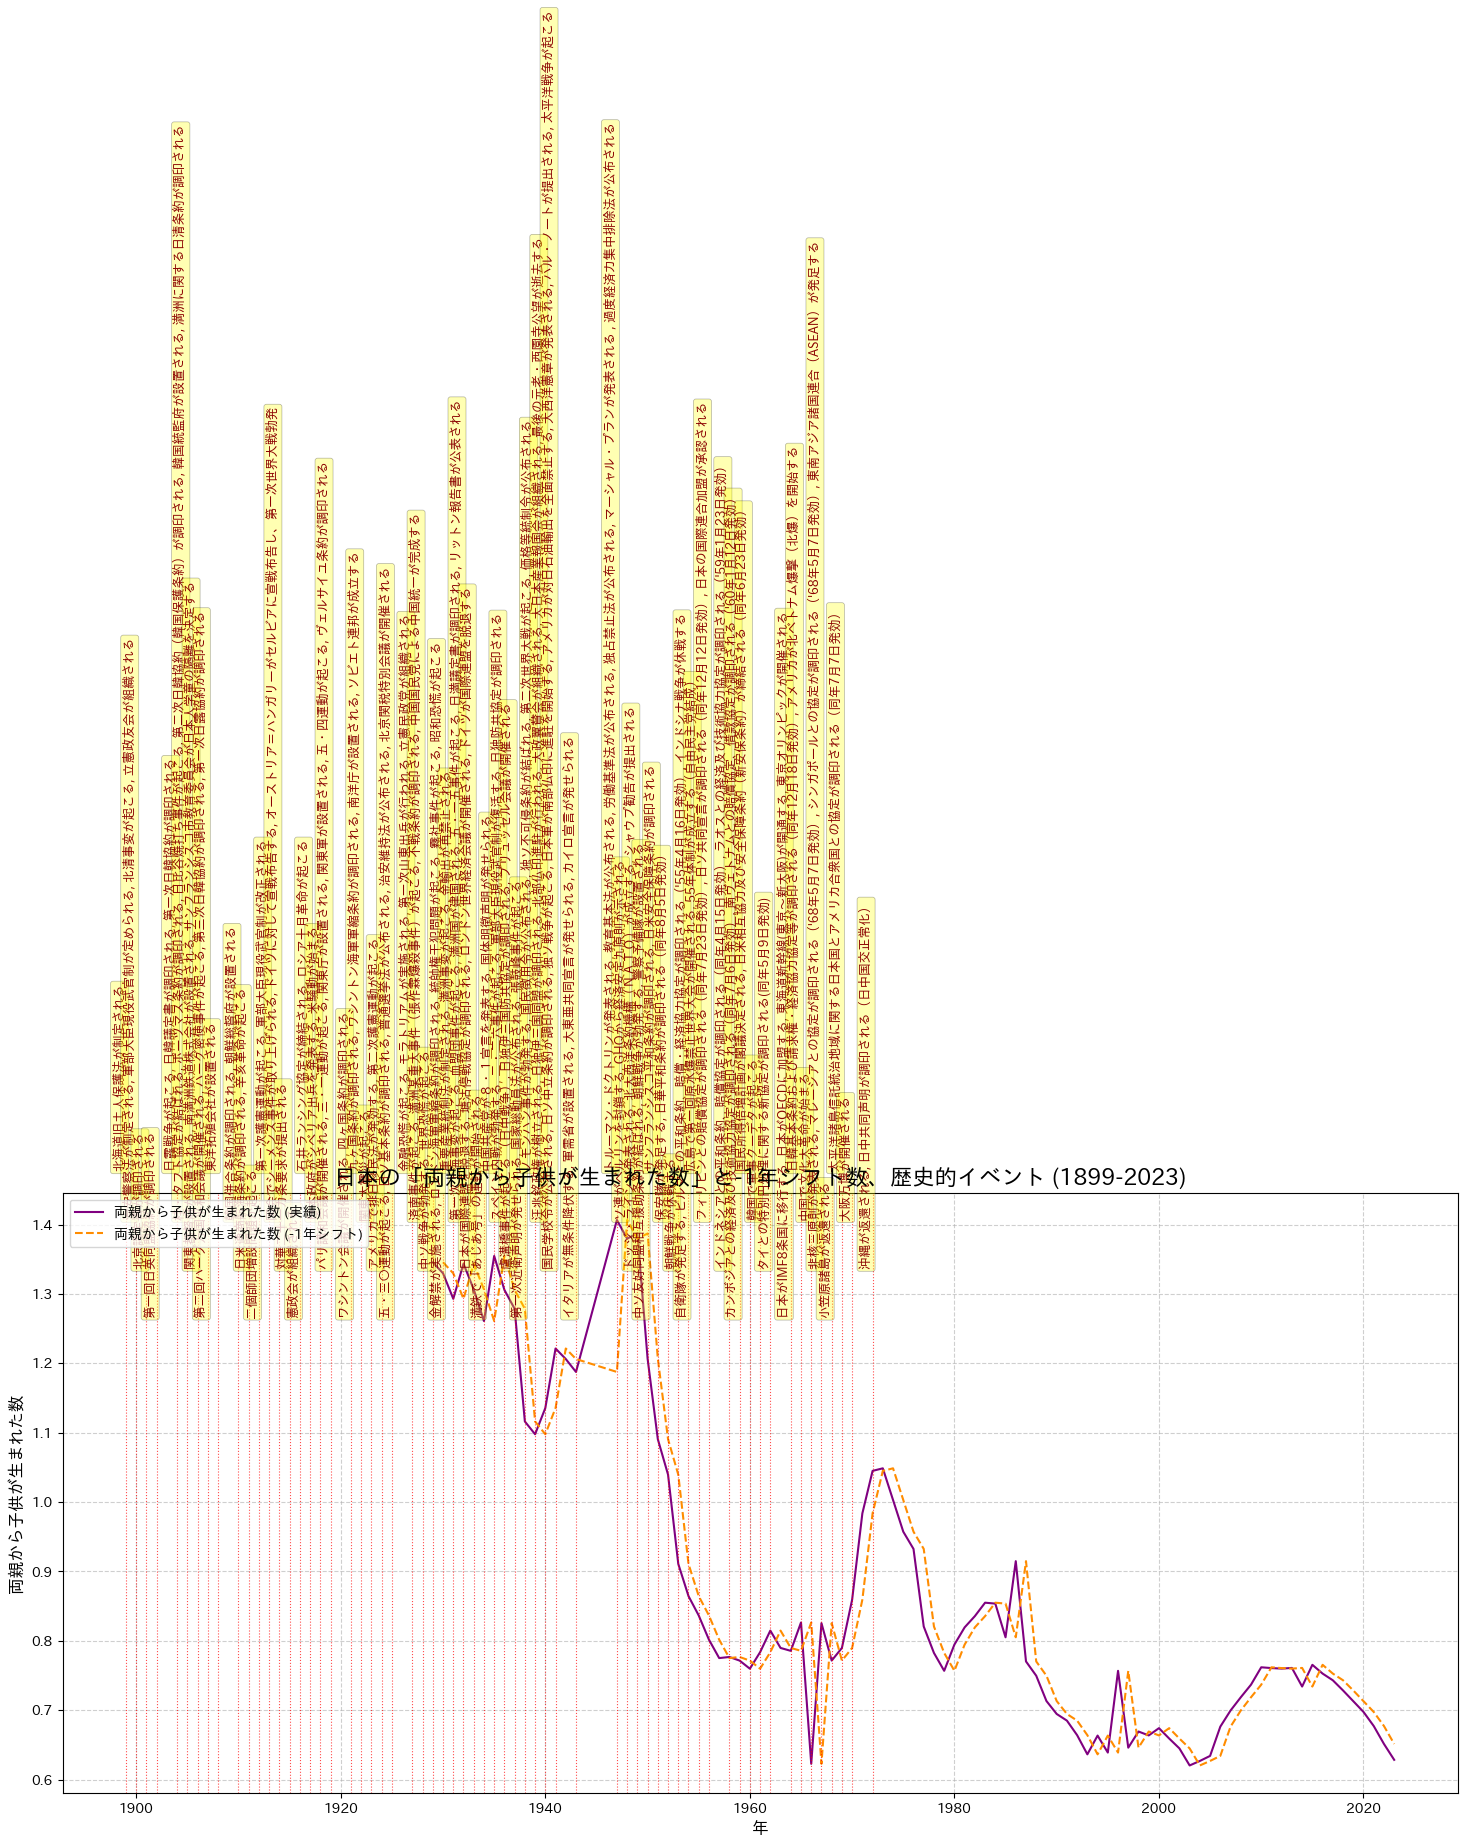

In [16]:
# Calculate children_per_generation shifted by -1 year
df_japan_birth_stats['children_per_generation_shifted_1_year'] = df_japan_birth_stats['children_per_generation'].shift(periods=-1, axis=0)

fig, ax1 = plt.subplots(figsize=(18, 10))

# Plot original 'children_per_generation' on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='children_per_generation', label='両親から子供が生まれた数 (実績)', color='purple', ax=ax1)

# Plot shifted 'children_per_generation' on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='children_per_generation_shifted_1_year', label='両親から子供が生まれた数 (-1年シフト)', color='darkorange', linestyle='--', ax=ax1)

ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('両親から子供が生まれた数', fontsize=12)
ax1.tick_params(axis='y')
ax1.grid(True, linestyle='--', alpha=0.6)

# Define y-positions for staggered annotations for historical events
max_children_per_gen_val = df_japan_birth_stats['children_per_generation'].max()
y_annotation_positions = [
    max_children_per_gen_val * 1.05,
    max_children_per_gen_val * 1.00,
    max_children_per_gen_val * 0.95,
    max_children_per_gen_val * 0.90
]

# Add vertical lines and annotations for historical events with staggering
# yearly_events is assumed to be defined from previous steps
if 'yearly_events' in locals() or 'yearly_events' in globals():
    for i, row in yearly_events.iterrows():
        ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7, linewidth=0.8)

        # Determine the staggered y-position for the current annotation
        y_pos = y_annotation_positions[i % len(y_annotation_positions)]

        # Annotate with event title
        ax1.text(row['year'], y_pos,
                 row['title'], rotation=90, verticalalignment='bottom',
                 horizontalalignment='right', fontsize=9, color='darkred',
                 bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="black", lw=0.5))

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc='upper left')

plt.title('日本の「両親から子供が生まれた数」と-1年シフト数、歴史的イベント (1899-2023)', fontsize=16)
fig.subplots_adjust(top=0.7, bottom=0.1) # Adjust subplot parameters to make room for annotations
plt.show()

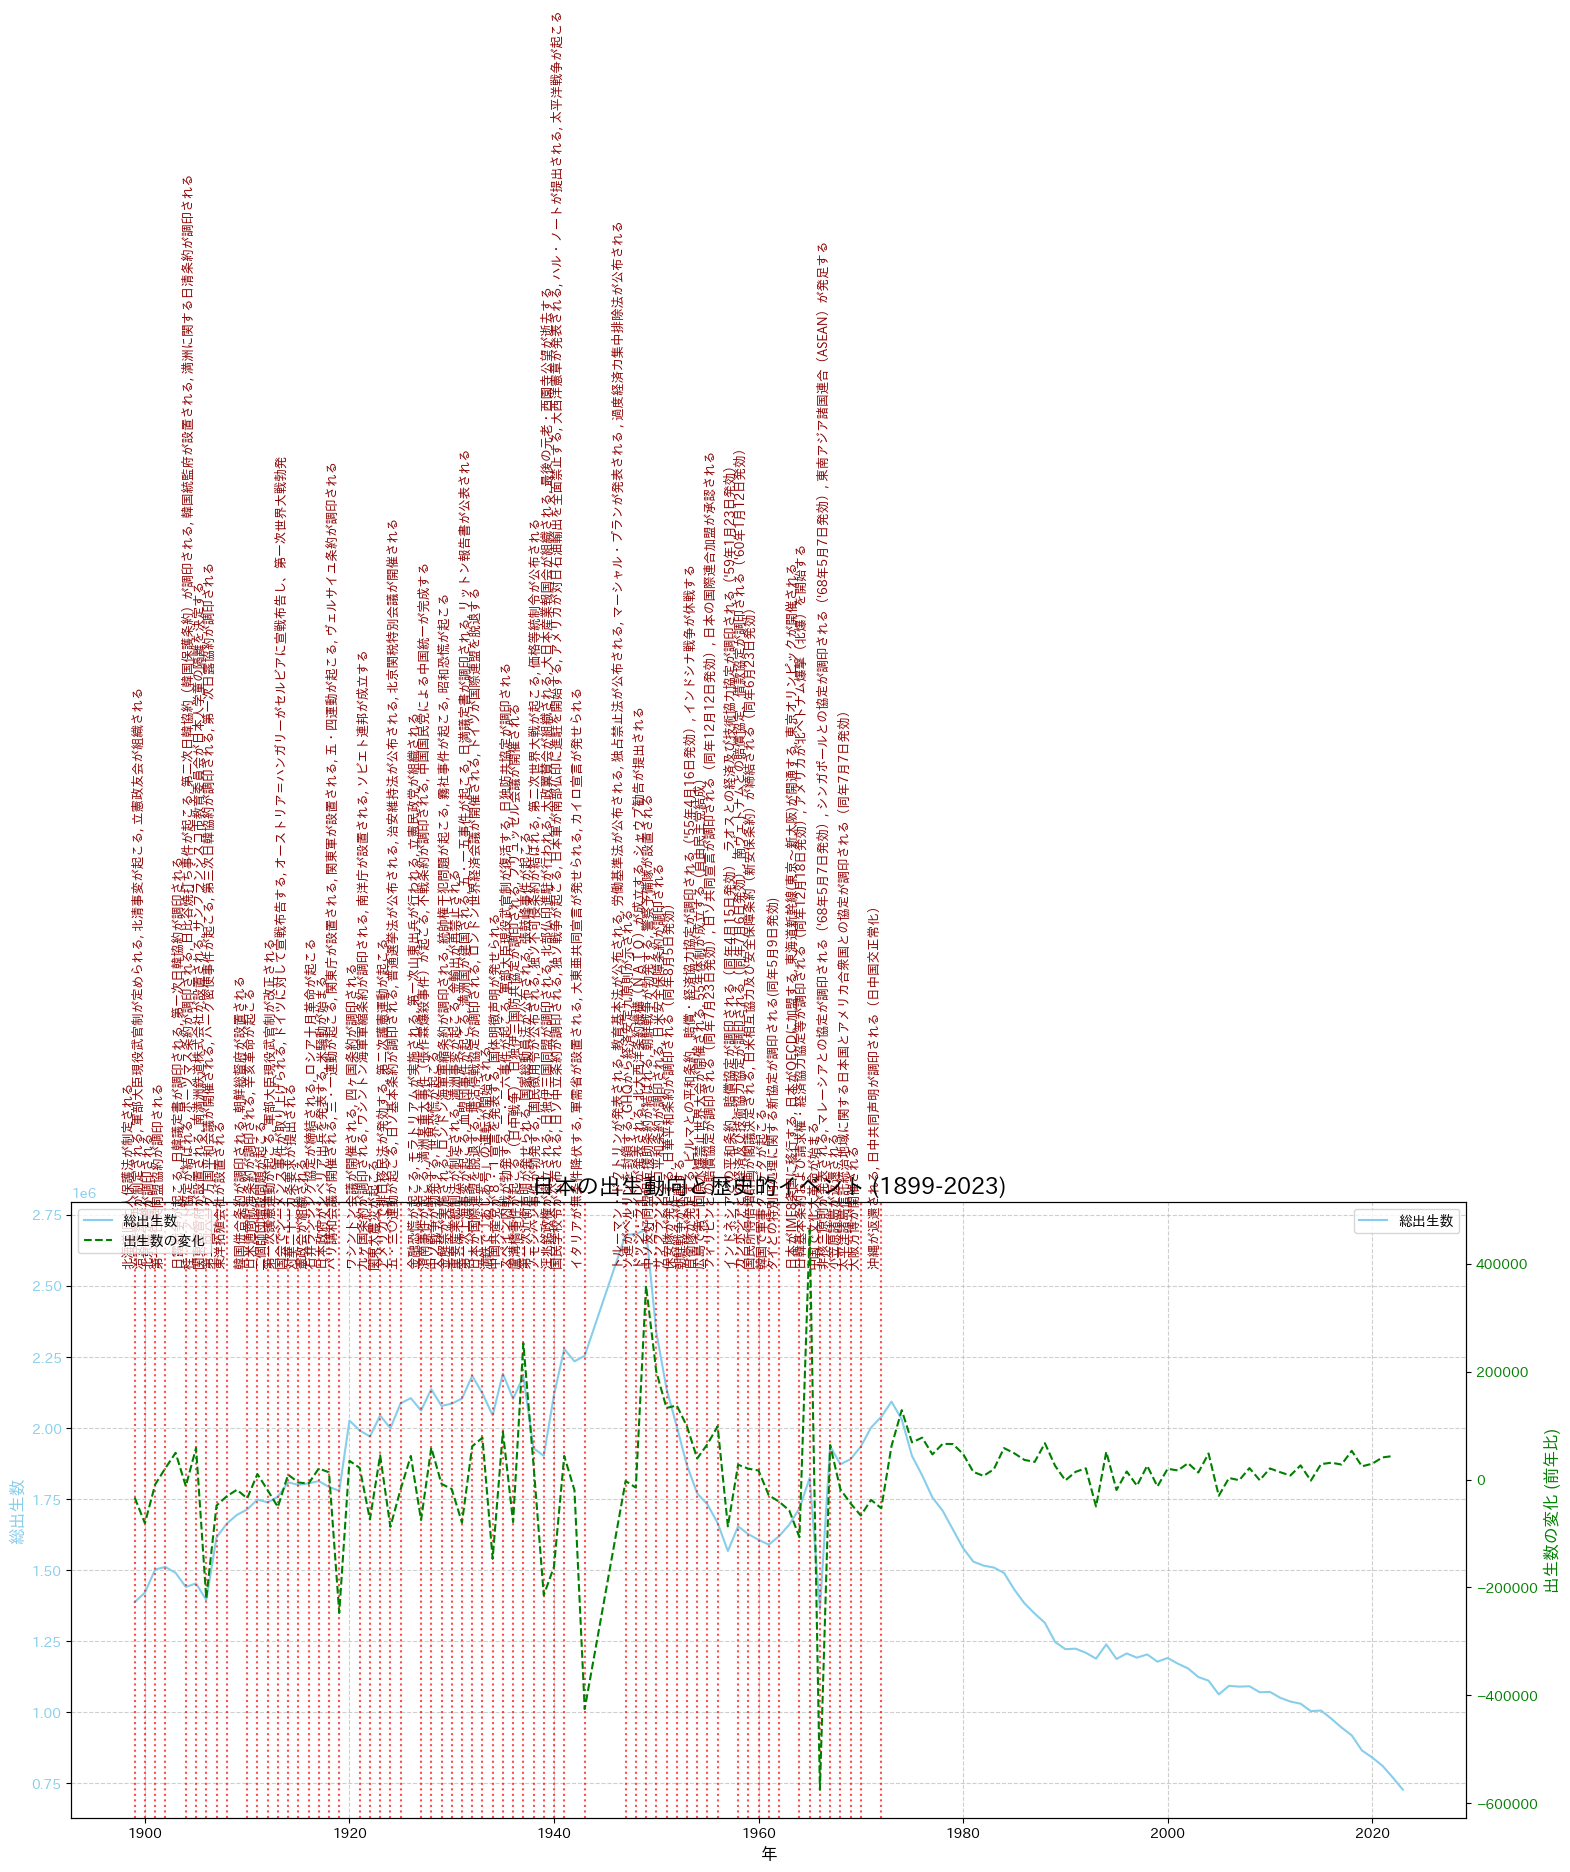

In [17]:
#傾きつまり年ごとの差分を取ってみる
# Calculate the year-over-year change in total births
df_japan_birth_stats['birth_change'] = df_japan_birth_stats['total_births'].diff()

fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot Total Births on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='総出生数', color='skyblue', ax=ax1)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('総出生数', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for Birth Change
ax2 = ax1.twinx()
sns.lineplot(data=df_japan_birth_stats, x='year', y='birth_change', label='出生数の変化', color='green', linestyle='--', ax=ax2)
ax2.set_ylabel('出生数の変化 (前年比)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add historical events (as previously defined)
yearly_events_for_plot = yearly_events # df_merged_data

# Add vertical lines and annotations for historical events
for index, row in yearly_events_for_plot.iterrows():
    # if index % 5 == 0: # Annotate every 5th event year for readability
    ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7)

    title_text = row['title']
    ax1.text(row['year'], df_japan_birth_stats['total_births'].max() * 0.95,
             title_text, rotation=90, verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, color='darkred')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16)
# plt.tight_layout()
plt.show()

/tmp/ipykernel_17/3042412561.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Adjust layout to prevent labels from overlapping


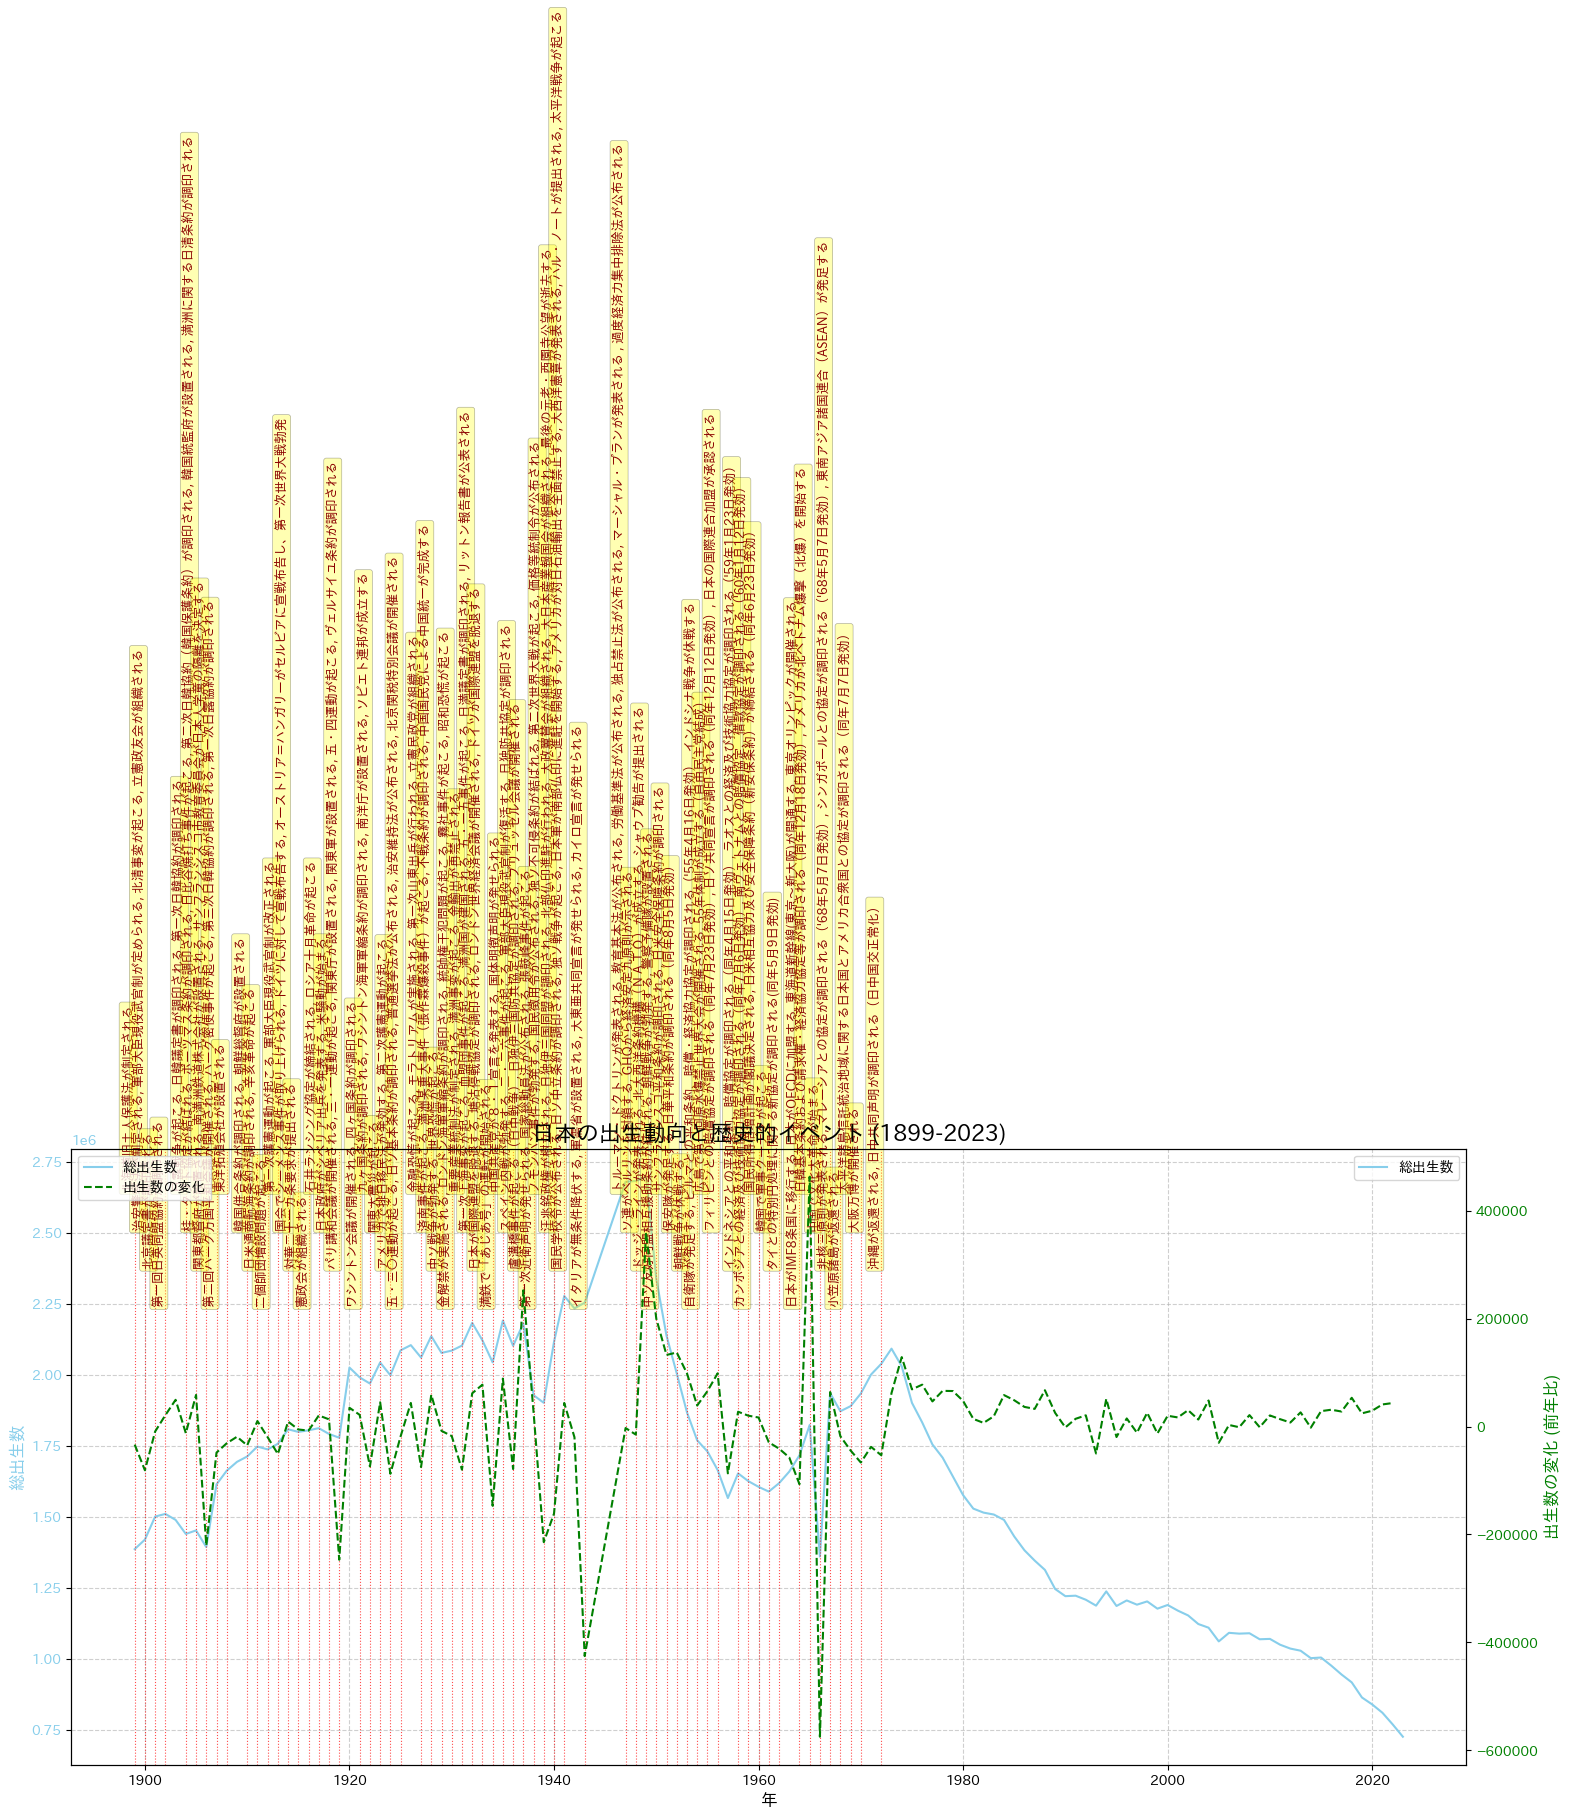

In [18]:

# Ensure 'birth_change' column is calculated (if not already from previous cells)
df_japan_birth_stats['birth_change'] = df_japan_birth_stats['total_births'].diff()

fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot Total Births on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='総出生数', color='skyblue', ax=ax1)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('総出生数', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for Birth Change
ax2 = ax1.twinx()
sns.lineplot(data=df_japan_birth_stats, x='year', y='birth_change', label='出生数の変化', color='green', linestyle='--', ax=ax2)
ax2.set_ylabel('出生数の変化 (前年比)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Define y-positions for staggered annotations
# Max value of total_births is used to position annotations relative to the top of the plot
max_births_val = df_japan_birth_stats['total_births'].max()
y_annotation_positions = [
    max_births_val * 0.98,
    max_births_val * 0.93,
    max_births_val * 0.88,
    max_births_val * 0.83
]

# Add vertical lines and annotations for historical events with staggering
# yearly_events is assumed to be defined from previous steps
for i, row in yearly_events.iterrows():
    ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7, linewidth=0.8)

    # Determine the staggered y-position for the current annotation
    y_pos = y_annotation_positions[i % len(y_annotation_positions)]

    # Annotate with event title
    ax1.text(row['year'], y_pos,
             row['title'], rotation=90, verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, color='darkred',
             bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="black", lw=0.5))

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

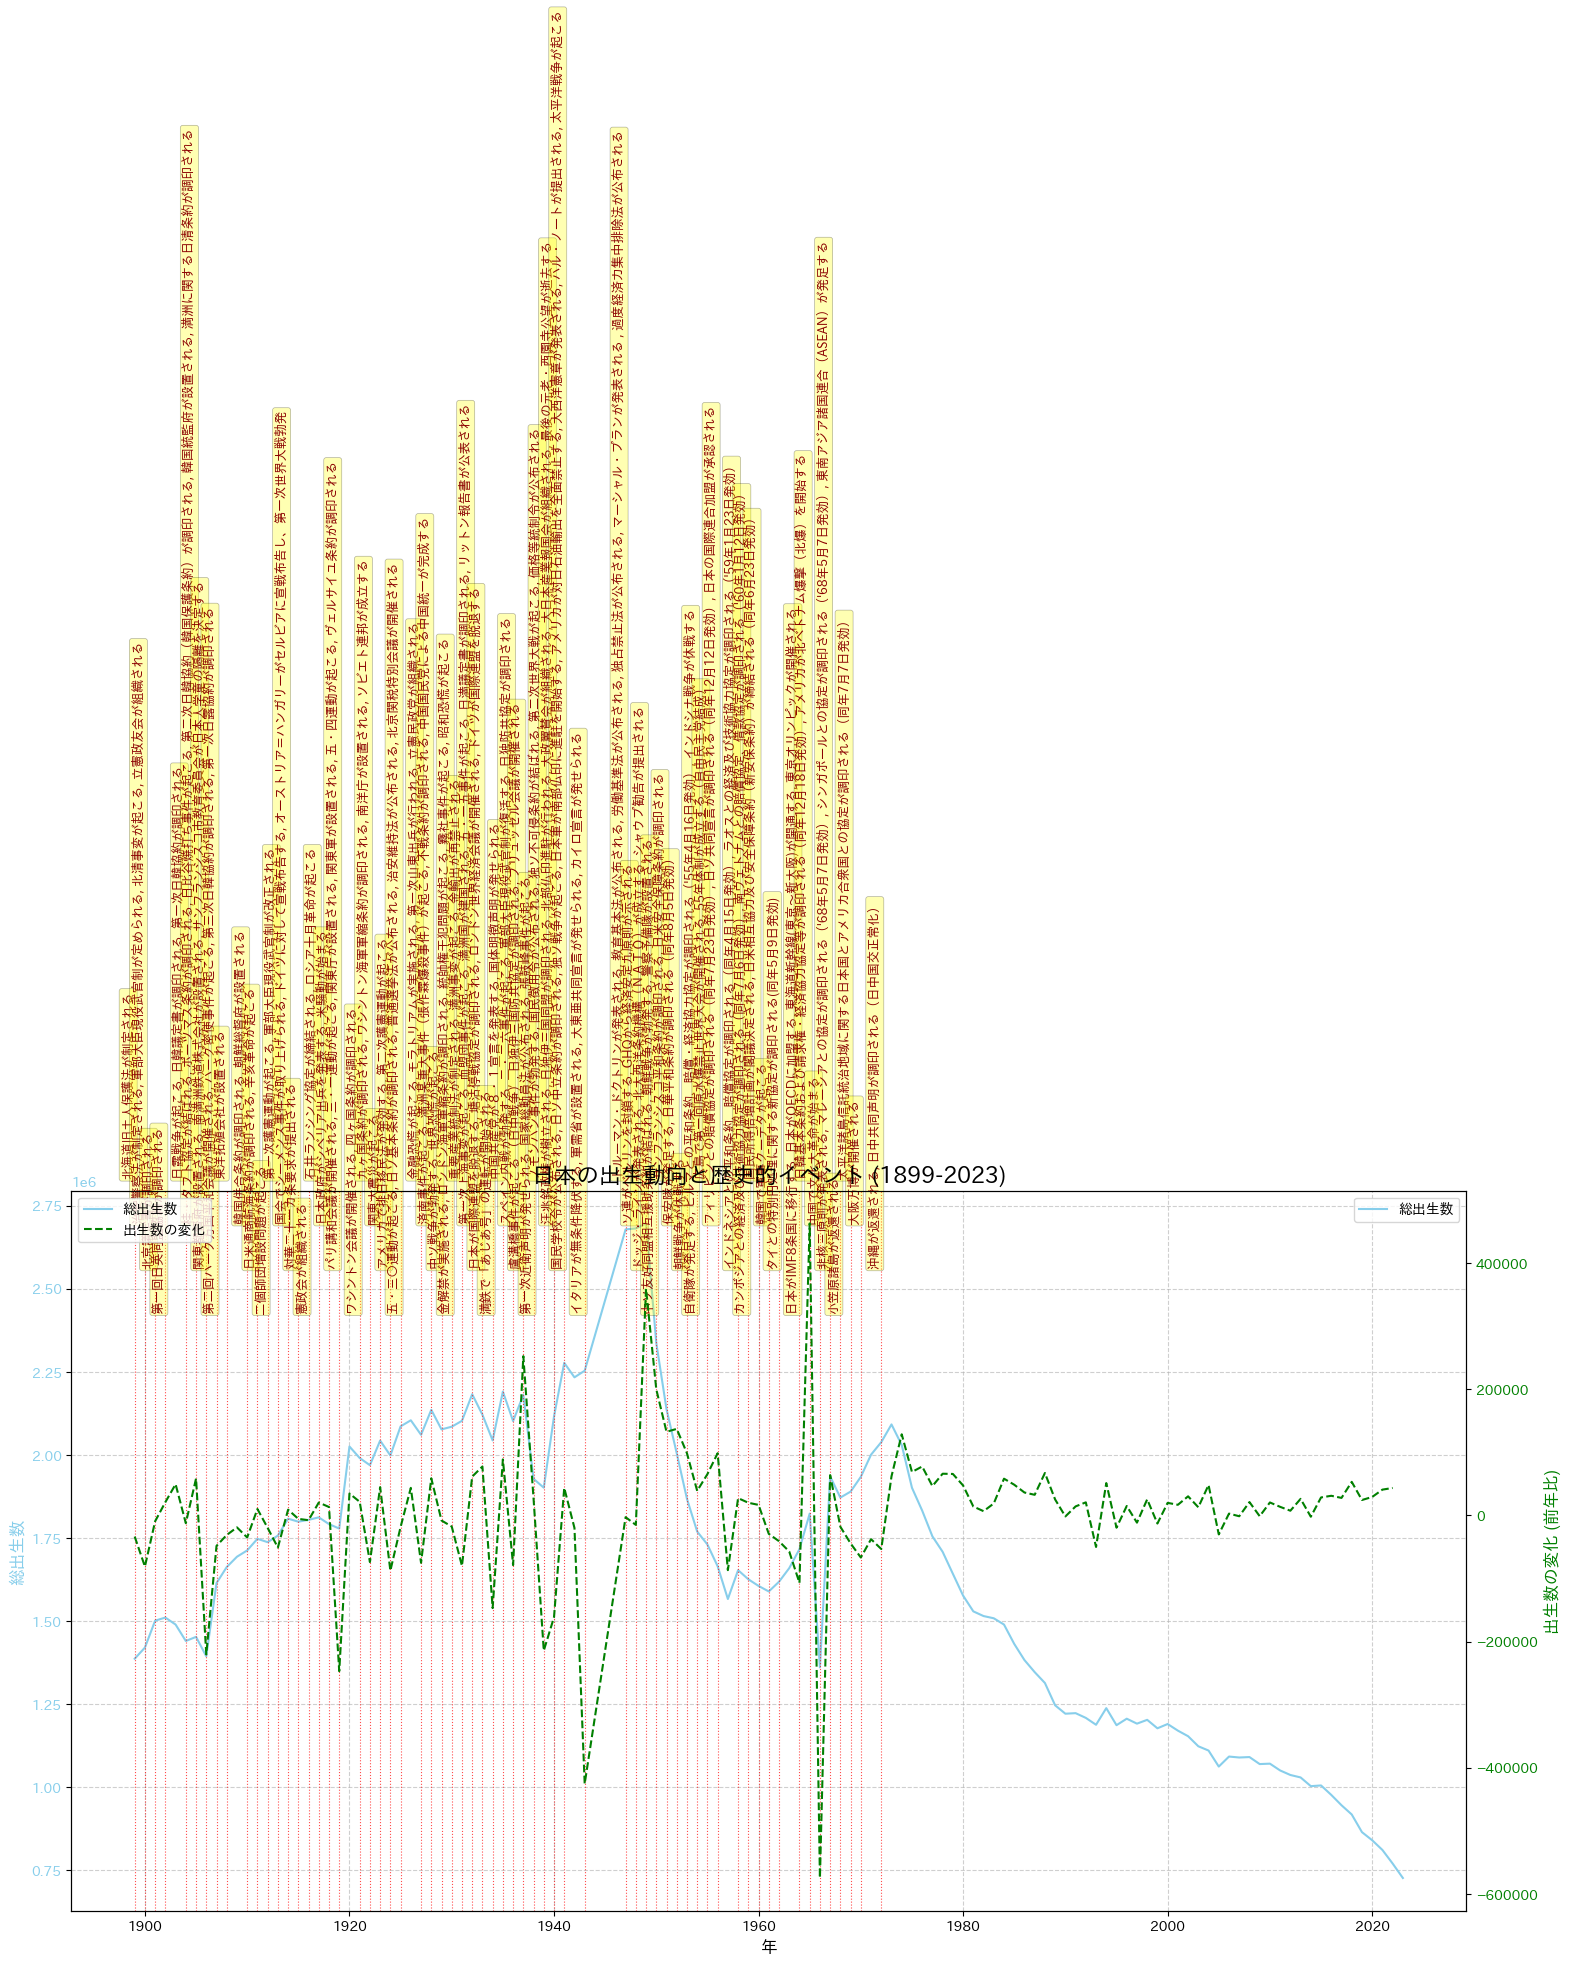

In [19]:

# Ensure 'birth_change' column is calculated (if not already from previous cells)
df_japan_birth_stats['birth_change'] = df_japan_birth_stats['total_births'].diff()

fig, ax1 = plt.subplots(figsize=(18, 12)) # Increased figure height

# Plot Total Births on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='総出生数', color='skyblue', ax=ax1)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('総出生数', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for Birth Change
ax2 = ax1.twinx()
sns.lineplot(data=df_japan_birth_stats, x='year', y='birth_change', label='出生数の変化', color='green', linestyle='--', ax=ax2)
ax2.set_ylabel('出生数の変化 (前年比)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Define y-positions for staggered annotations
# Max value of total_births is used to position annotations relative to the top of the plot
max_births_val = df_japan_birth_stats['total_births'].max()
# Adjusted y-annotation positions to be lower to better fit within the plot area after rotation
y_annotation_positions = [
    max_births_val * 1.05, # Positioned slightly above the max birth value
    max_births_val * 1.00,
    max_births_val * 0.95,
    max_births_val * 0.90
]

# Add vertical lines and annotations for historical events with staggering
# yearly_events is assumed to be defined from previous steps
for i, row in yearly_events.iterrows():
    ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7, linewidth=0.8)

    # Determine the staggered y-position for the current annotation
    y_pos = y_annotation_positions[i % len(y_annotation_positions)]

    # Annotate with event title
    ax1.text(row['year'], y_pos,
             row['title'], rotation=90, verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, color='darkred',
             bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="black", lw=0.5))

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16)
# Adjust subplot parameters to make room for annotations at the top
fig.subplots_adjust(top=0.7, bottom=0.1)
# plt.tight_layout() # Removed as subplots_adjust is used for finer control
plt.show()

df_yearly_event_title_length head:


/tmp/ipykernel_17/232210997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline['title_length'] = df_timeline['title'].str.len()


,year,total_event_title_length
0,1840,11
1,1842,10
2,1853,46
3,1854,12
4,1855,12


df_births_and_events_length head:


,year,total_births,total_event_title_length
0,1972,2038682,29
1,1970,1934239,10
2,1969,1889815,46
3,1968,1871839,11
4,1967,1935647,87


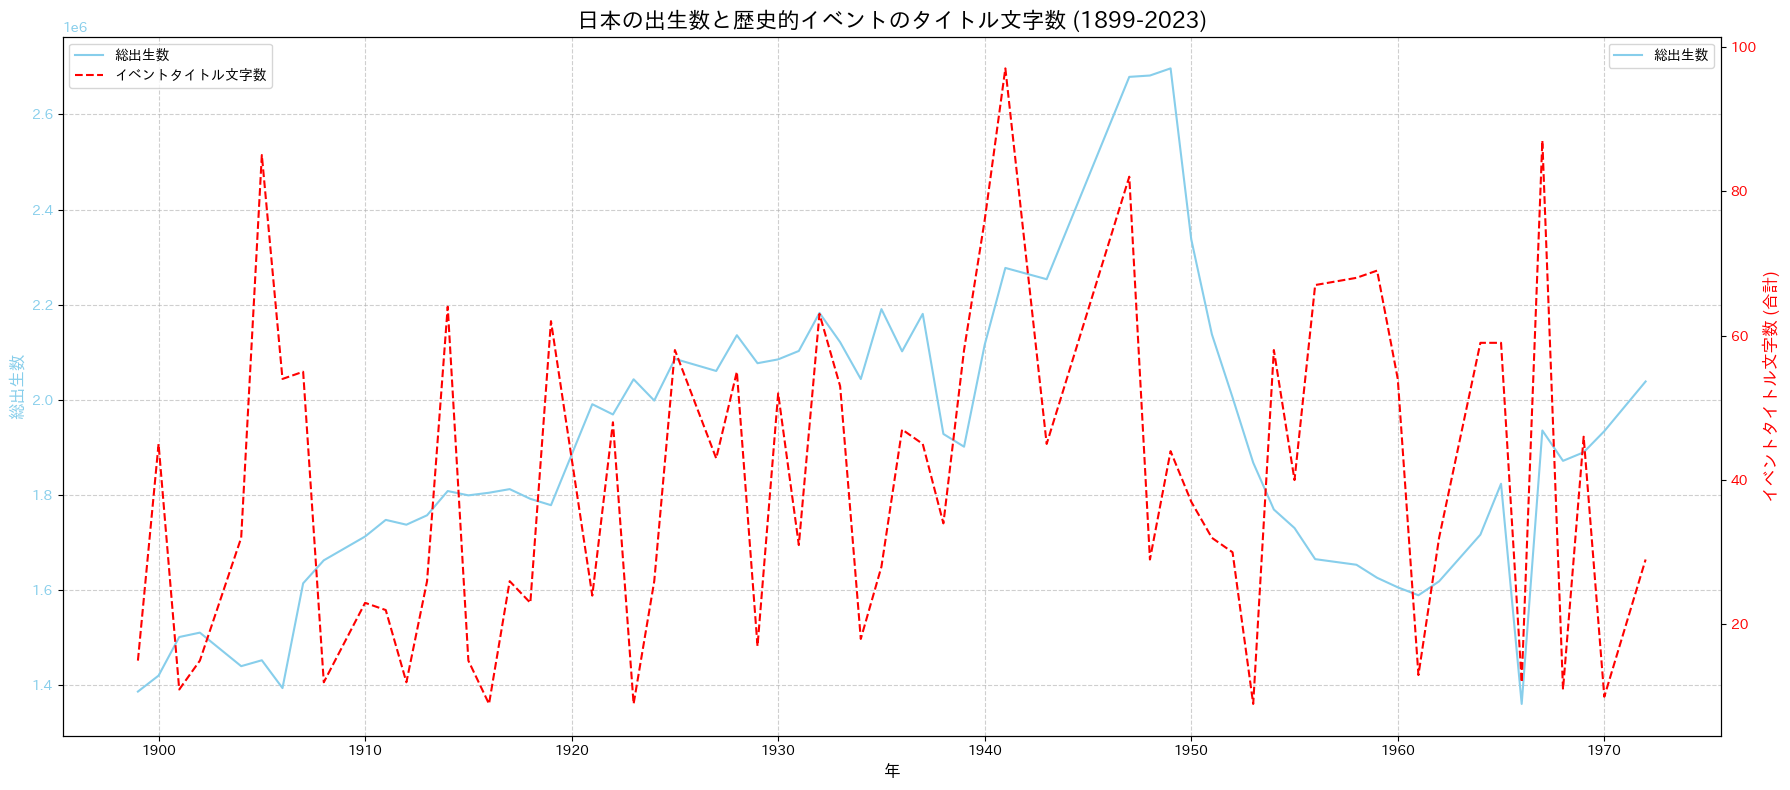

In [20]:


# 1. Add a new column named `title_length` to the `df_timeline` DataFrame
df_timeline['title_length'] = df_timeline['title'].str.len()

# 2. Group the `df_timeline` DataFrame by 'year' and calculate the sum of `title_length`
df_yearly_event_title_length = df_timeline.groupby('year')['title_length'].sum().reset_index()
df_yearly_event_title_length.rename(columns={'title_length': 'total_event_title_length'}, inplace=True)

print("df_yearly_event_title_length head:")
display(df_yearly_event_title_length.head())

# 3. Merge `df_yearly_event_title_length` with `df_japan_birth_stats` on the 'year' column
df_births_and_events_length = pd.merge(
    df_japan_birth_stats[['year', 'total_births']], # Select relevant columns to avoid redundancy
    df_yearly_event_title_length,
    on='year',
    how='inner'
)

print("df_births_and_events_length head:")
display(df_births_and_events_length.head())

# 4. Create a figure and a twin y-axis plot to visualize the data
fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot 'total_births' on primary y-axis
sns.lineplot(
    data=df_births_and_events_length, x='year', y='total_births', 
    label='総出生数', color='skyblue', ax=ax1
)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('総出生数', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for 'total_event_title_length'
ax2 = ax1.twinx()
sns.lineplot(
    data=df_births_and_events_length, x='year', y='total_event_title_length', 
    label='イベントタイトル文字数', color='red', linestyle='--', ax=ax2
)
ax2.set_ylabel('イベントタイトル文字数 (合計)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 5. Set appropriate Japanese titles and labels
plt.title('日本の出生数と歴史的イベントのタイトル文字数 (1899-2023)', fontsize=16)

# 6. Add a legend to distinguish between the two lines and display the plot
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [21]:
yearly_events

,year,title
0,1899,北海道旧土人保護法が制定される
1,1900,"治安警察法が制定される, 軍部大臣現役武官制が定められる, 北清事変が起こる, 立憲政友会が..."
2,1901,北京議定書が調印される
3,1902,第一回日英同盟協約が調印される
4,1904,"日露戦争が起こる, 日韓議定書が調印される, 第一次日韓協約が調印される"
...,...,...
58,1967,"非核三原則が発表される, マレーシアとの協定が調印される（'68年5月7日発効）, シンガポ..."
59,1968,小笠原諸島が返還される
60,1969,太平洋諸島信託統治地域に関する日本国とアメリカ合衆国との協定が調印される（同年7月7日発効）
61,1970,大阪万博が開催される


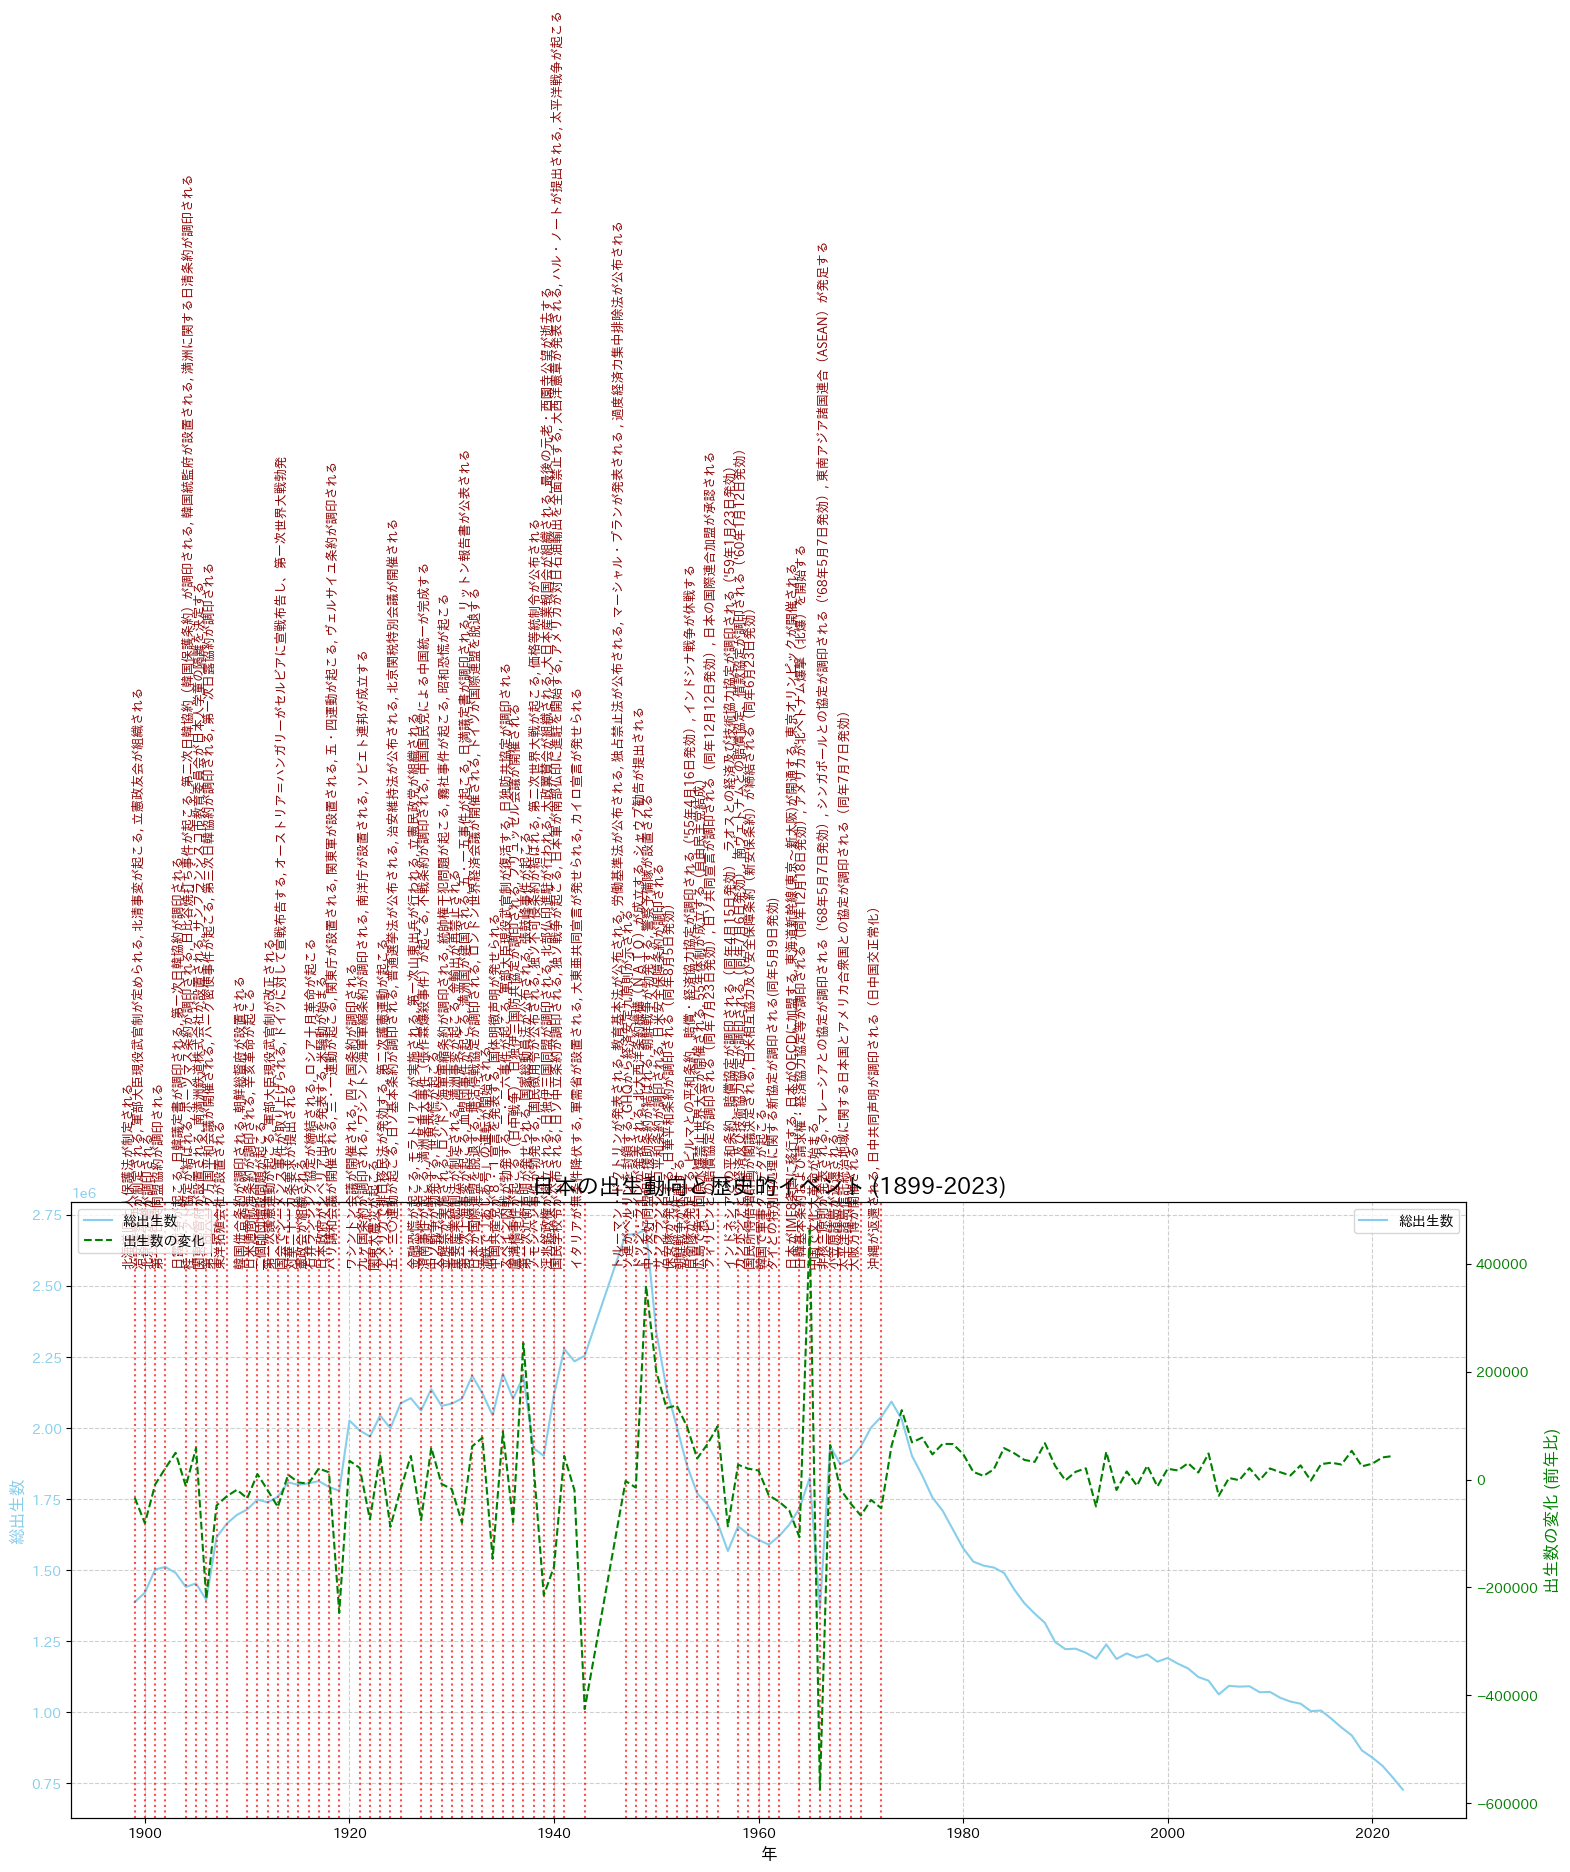

In [22]:
#傾きつまり年ごとの差分を取ってみる
# Calculate the year-over-year change in total births
df_japan_birth_stats['birth_change'] = df_japan_birth_stats['total_births'].diff()

fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot Total Births on primary y-axis
sns.lineplot(data=df_japan_birth_stats, x='year', y='total_births', label='総出生数', color='skyblue', ax=ax1)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('総出生数', fontsize=12, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for Birth Change
ax2 = ax1.twinx()
sns.lineplot(data=df_japan_birth_stats, x='year', y='birth_change', label='出生数の変化', color='green', linestyle='--', ax=ax2)
ax2.set_ylabel('出生数の変化 (前年比)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add historical events (as previously defined)
yearly_events_for_plot = yearly_events # df_merged_data

# Add vertical lines and annotations for historical events
for index, row in yearly_events_for_plot.iterrows():
    # if index % 5 == 0: # Annotate every 5th event year for readability
    ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7)

    title_text = row['title']
    ax1.text(row['year'], df_japan_birth_stats['total_births'].max() * 0.95,
             title_text, rotation=90, verticalalignment='bottom',
             horizontalalignment='right', fontsize=9, color='darkred')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('日本の出生動向と歴史的イベント (1899-2023)', fontsize=16)
# plt.tight_layout()
plt.show()

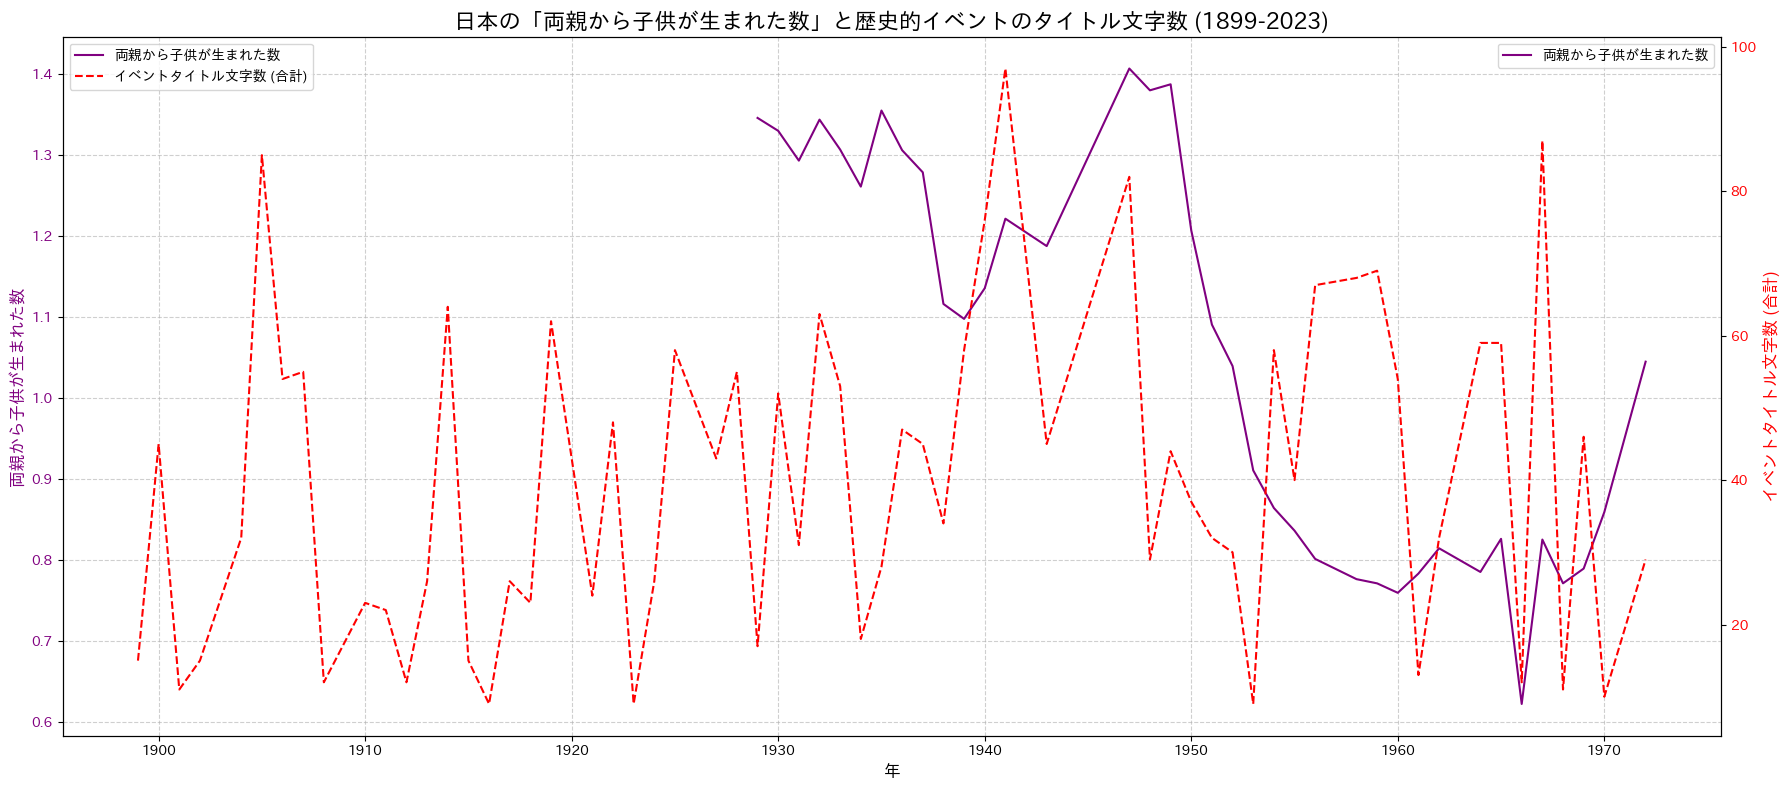

In [23]:

# Ensure df_correlation_data is available by merging if not already
# This step re-merges for robustness, assuming df_japan_birth_stats and df_yearly_event_title_length are up-to-date
df_correlation_data = pd.merge(
    df_japan_birth_stats[['year', 'children_per_generation']],
    df_yearly_event_title_length, # df_yearly_event_title_length should be available from previous steps
    on='year',
    how='inner'
)

fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot 'children_per_generation' on primary y-axis
sns.lineplot(
    data=df_correlation_data, x='year', y='children_per_generation',
    label='両親から子供が生まれた数', color='purple', ax=ax1
)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('両親から子供が生まれた数', fontsize=12, color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for 'total_event_title_length'
ax2 = ax1.twinx()
sns.lineplot(
    data=df_correlation_data, x='year', y='total_event_title_length',
    label='イベントタイトル文字数 (合計)', color='red', linestyle='--', ax=ax2
)
ax2.set_ylabel('イベントタイトル文字数 (合計)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('日本の「両親から子供が生まれた数」と歴史的イベントのタイトル文字数 (1899-2023)', fontsize=16)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

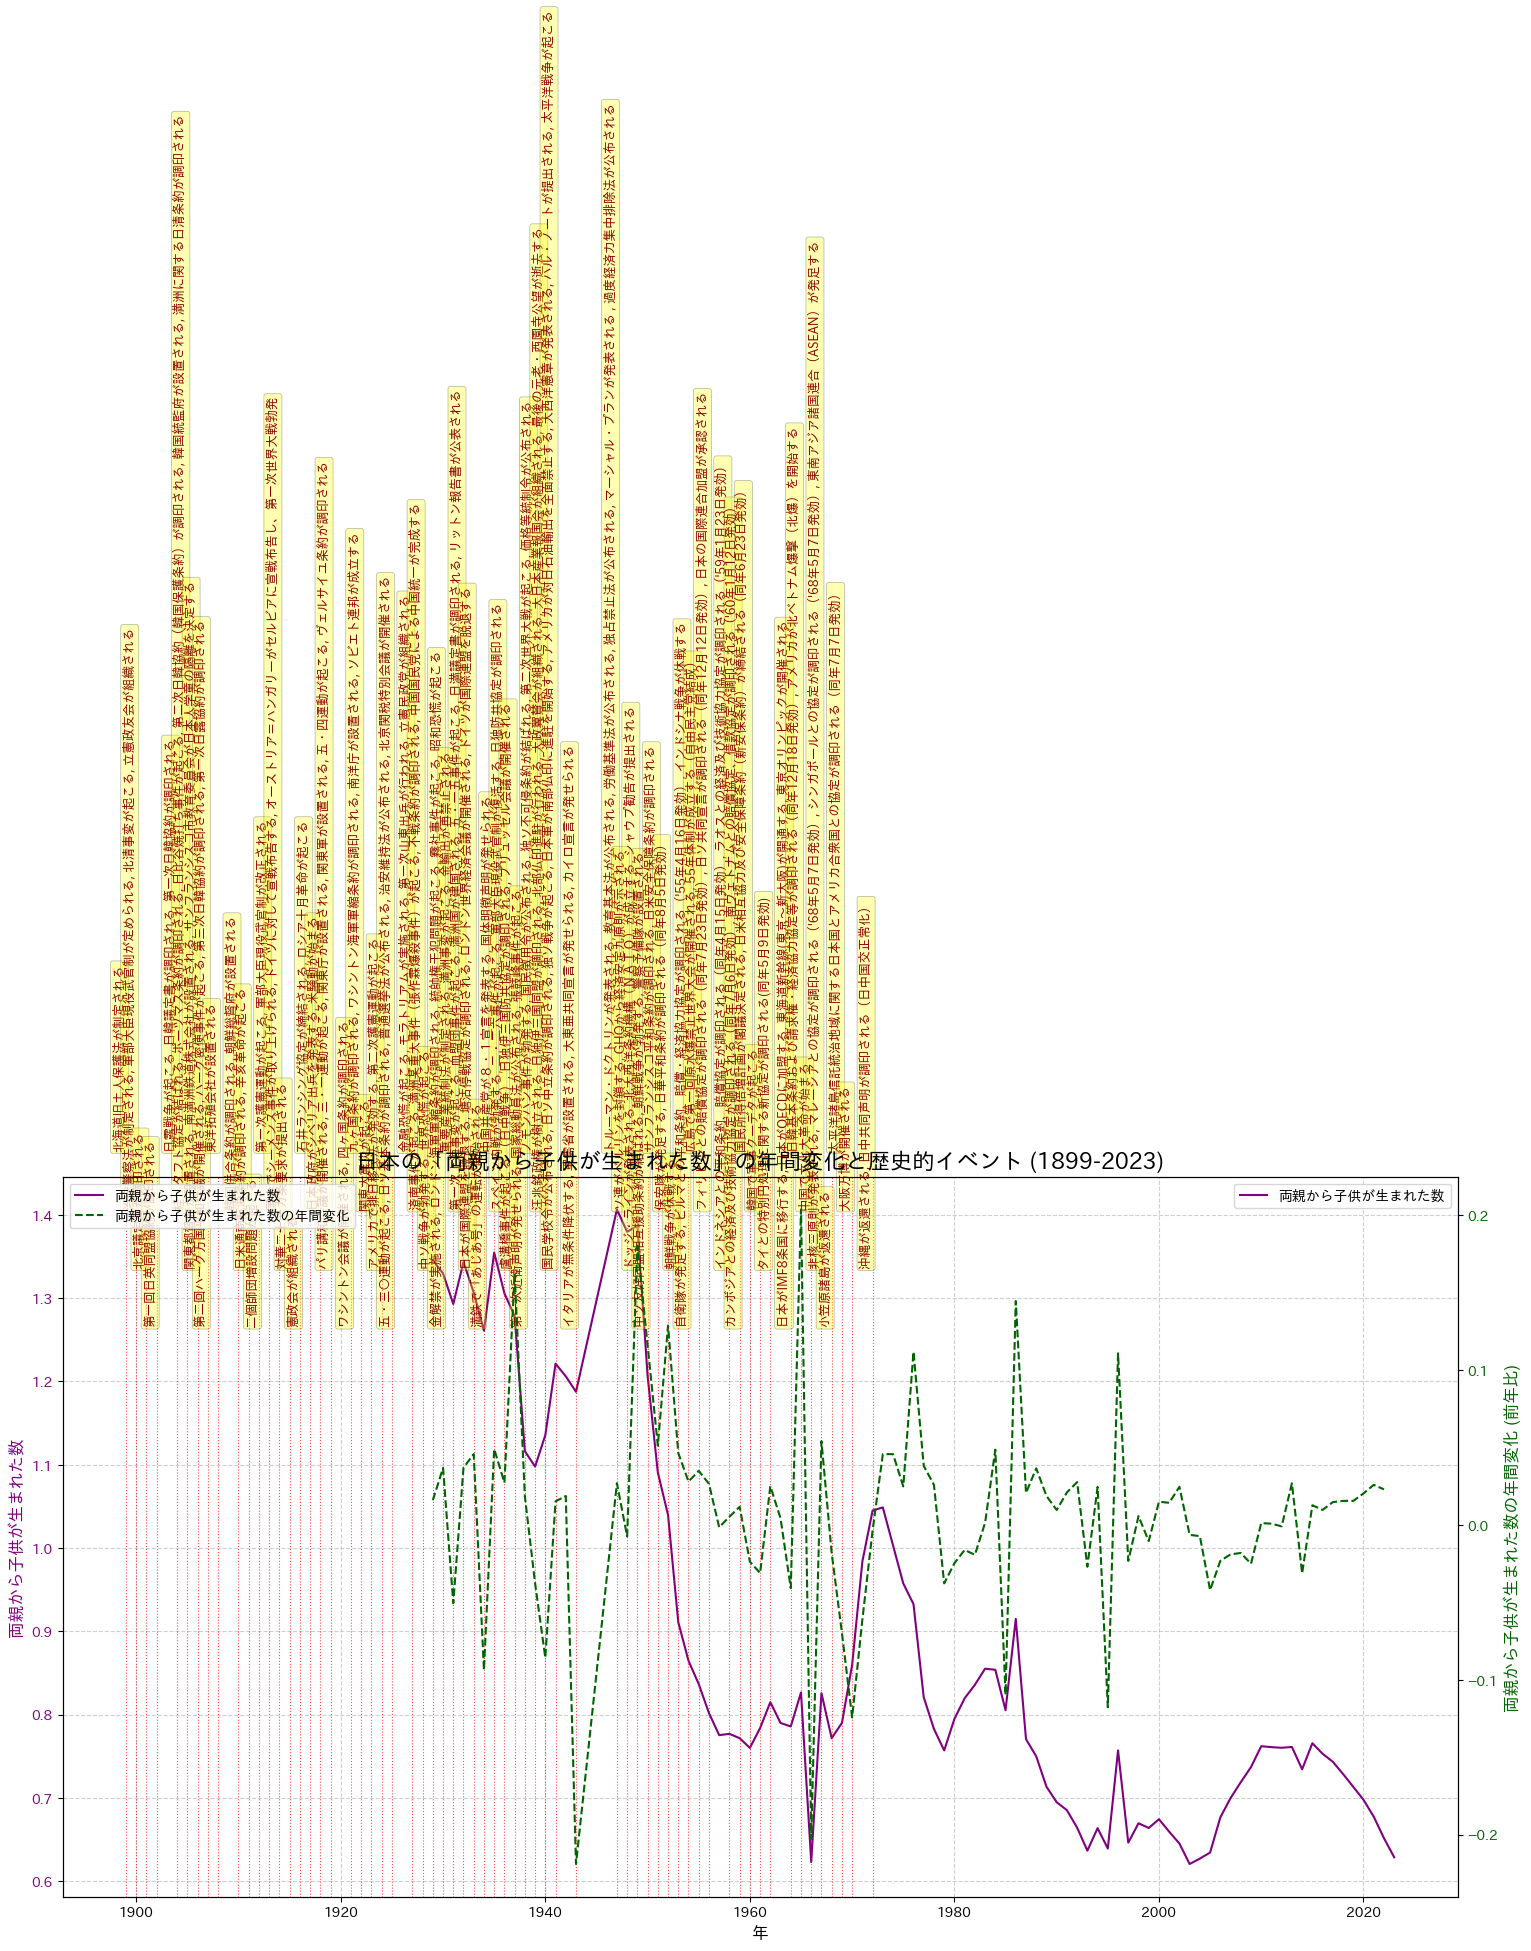

In [24]:

# 1. Calculate the year-over-year difference for 'children_per_generation'
df_japan_birth_stats['children_per_generation_difference'] = df_japan_birth_stats['children_per_generation'].diff()

# 2. Create a figure with a primary y-axis for 'children_per_generation' and a secondary y-axis for its difference
fig, ax1 = plt.subplots(figsize=(18, 12)) # Increased figure height for annotations

# 3. Plot 'children_per_generation' on the primary y-axis
sns.lineplot(
    data=df_japan_birth_stats, x='year', y='children_per_generation',
    label='両親から子供が生まれた数', color='purple', ax=ax1
)
ax1.set_xlabel('年', fontsize=12)
ax1.set_ylabel('両親から子供が生まれた数', fontsize=12, color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for 'children_per_generation_difference'
ax2 = ax1.twinx()
sns.lineplot(
    data=df_japan_birth_stats, x='year', y='children_per_generation_difference',
    label='両親から子供が生まれた数の年間変化', color='darkgreen', linestyle='--', ax=ax2
)
ax2.set_ylabel('両親から子供が生まれた数の年間変化 (前年比)', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# Define y-positions for staggered annotations for historical events
# Max value of children_per_generation is used to position annotations relative to the top of the plot
max_children_per_gen_val = df_japan_birth_stats['children_per_generation'].max()
y_annotation_positions = [
    max_children_per_gen_val * 1.05,
    max_children_per_gen_val * 1.00,
    max_children_per_gen_val * 0.95,
    max_children_per_gen_val * 0.90
]

# 4 & 5. Add vertical lines and annotations for historical events with staggering
# yearly_events is assumed to be defined from previous steps
if 'yearly_events' in locals() or 'yearly_events' in globals():
    for i, row in yearly_events.iterrows():
        ax1.axvline(x=row['year'], color='red', linestyle=':', alpha=0.7, linewidth=0.8)

        # Determine the staggered y-position for the current annotation
        y_pos = y_annotation_positions[i % len(y_annotation_positions)]

        # Annotate with event title
        ax1.text(row['year'], y_pos,
                 row['title'], rotation=90, verticalalignment='bottom',
                 horizontalalignment='right', fontsize=9, color='darkred',
                 bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="black", lw=0.5))

# 7. Add a combined legend for both line plots
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# 6. Set appropriate Japanese titles and labels
plt.title('日本の「両親から子供が生まれた数」の年間変化と歴史的イベント (1899-2023)', fontsize=16)

# 8. Adjust subplot parameters to make room for annotations at the top
fig.subplots_adjust(top=0.7, bottom=0.1)

# 9. Display the plot
plt.show()

In [25]:
import pandas as pd

# 1. Create a new DataFrame df_events_dummy from yearly_events
#    and add a new column named `event_occurred` with value 1.
df_events_dummy = yearly_events[['year']].drop_duplicates().copy()
df_events_dummy['event_occurred'] = 1

print("df_events_dummy head:")
display(df_events_dummy.head())

# 2. Merge df_japan_birth_stats with df_events_dummy on the 'year' column using a left merge.
df_statistical_analysis = pd.merge(
    df_japan_birth_stats,
    df_events_dummy,
    on='year',
    how='left'
)

# 3. Fill any NaN values in the newly merged `event_occurred` column with 0.
df_statistical_analysis['event_occurred'] = df_statistical_analysis['event_occurred'].fillna(0)

# 4. Ensure the `event_occurred` column is of integer type.
df_statistical_analysis['event_occurred'] = df_statistical_analysis['event_occurred'].astype(int)

print("\nDataFrame for Statistical Analysis head:")
display(df_statistical_analysis.head())

print("\nDataFrame for Statistical Analysis info:")
df_statistical_analysis.info()


import scipy.stats as stats
import numpy as np

# Filter out NaN values from 'children_per_generation' before statistical testing
df_filtered = df_statistical_analysis.dropna(subset=['children_per_generation'])

# Separate 'children_per_generation' into two groups based on 'event_occurred'
children_with_events = df_filtered[df_filtered['event_occurred'] == 1]['children_per_generation']
children_without_events = df_filtered[df_filtered['event_occurred'] == 0]['children_per_generation']

print(f"Number of years with events: {len(children_with_events)}")
print(f"Number of years without events: {len(children_without_events)}")

# Perform an independent samples t-test
# We assume unequal variances (Welch's t-test) as a more robust approach
t_stat, p_value = stats.ttest_ind(children_with_events, children_without_events, equal_var=False)

print(f"\nIndependent Samples t-test Results:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
print(f"  Alpha (significance level): {alpha}")
if p_value < alpha:
    print("  Conclusion: Reject the null hypothesis. There is a statistically significant difference in 'children_per_generation' between years with and without historical events.")
else:
    print("  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in 'children_per_generation' between years with and without historical events.")

print(f"\nMean 'children_per_generation' in years with events: {children_with_events.mean():.3f}")
print(f"Mean 'children_per_generation' in years without events: {children_without_events.mean():.3f}")


df_events_dummy head:


,year,event_occurred
0,1899,1
1,1900,1
2,1901,1
3,1902,1
4,1904,1



DataFrame for Statistical Analysis head:


,year,total_births,male_births,female_births,female_births_shifted_20,male_births_shifted_30,total_shifted_female_and_male,children_per_generation,children_per_generation_shifted_1_year,birth_change,children_per_generation_difference,event_occurred
0,2023,727288,372603,354685,546874.0,610244.0,1157118.0,0.628534,0.651446,NaN,NaN,0
1,2022,770759,395257,375502,561015.0,622136.0,1183151.0,0.651446,0.677278,43471.0,0.022912,0
2,2021,811622,415903,395719,569744.0,628615.0,1198359.0,0.677278,0.697574,40863.0,0.025832,0
3,2020,840835,430713,410122,578399.0,626971.0,1205370.0,0.697574,0.713066,29213.0,0.020296,0
4,2019,865239,443430,421809,572900.0,640506.0,1213406.0,0.713066,0.728533,24404.0,0.015492,0



DataFrame for Statistical Analysis info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   year                                    122 non-null    int64  
 1   total_births                            122 non-null    int64  
 2   male_births                             122 non-null    int64  
 3   female_births                           122 non-null    int64  
 4   female_births_shifted_20                102 non-null    float64
 5   male_births_shifted_30                  92 non-null     float64
 6   total_shifted_female_and_male           92 non-null     float64
 7   children_per_generation                 92 non-null     float64
 8   children_per_generation_shifted_1_year  91 non-null     float64
 9   birth_change                            121 non-null    float64
 10  children_per_generat